# Phase 1: Data Collection and Structurally Faithful Preprocessing

This notebook pulls the raw financial datasets (FinQA for fine-tuning, FinanceBench for evaluation) and applies heuristic layout parsing.
It produces structured Markdown tables, generates CoT prompts, and includes comprehensive EDA with multiple visualizations.

## Environment Setup

Install or update data processing, visualization, and tokenization libraries.

In [1]:
%pip -q install "datasets>=2.18.0" "pandas>=2.2.0" "numpy>=1.26.0" "matplotlib>=3.8.0" "seaborn>=0.13.0" "tqdm>=4.66.0" "transformers>=4.40.0" "wordcloud>=1.9.0"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount("/content/drive", force_remount=False)

# Define search locations for the project root
candidate_roots = [
    Path("/content/drive/MyDrive/FinGEO-SLM"),
    Path("/content/FinGEO-SLM"),
    Path.cwd()
]

# Identify PROJECT_ROOT by checking for the 'data/finQA' directory structure
PROJECT_ROOT = Path.cwd()
for p in candidate_roots:
    if p.exists() and (p / "data" / "finQA").exists():
        PROJECT_ROOT = p
        break

os.chdir(PROJECT_ROOT)
print(f"Project root set to: {PROJECT_ROOT}")

def project_path(*parts):
    return str(PROJECT_ROOT.joinpath(*parts))

# Verify the specific file exists
finqa_train = project_path("data", "finQA", "train.json")
if os.path.exists(finqa_train):
    print(f"Confirmed: Found train.json at {finqa_train}")
else:
    print(f"Warning: train.json not found at {finqa_train}. Please check the folder structure.")

Project root set to: /Users/uzmanarfan/Documents/FinGEO-SLM
Confirmed: Found train.json at /Users/uzmanarfan/Documents/FinGEO-SLM/data/finQA/train.json


In [3]:
# Google Drive Integration - Auto-mount on Colab
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    try:
        from google.colab import drive
        print("📁 Mounting Google Drive...")
        drive.mount('/content/drive', force_remount=False)
        print("✓ Google Drive mounted successfully at /content/drive")
        print("✓ Your files will be accessible at: /content/drive/MyDrive/FinGEO-SLM/")
    except Exception as e:
        print(f"⚠ Warning: Could not mount Google Drive: {e}")
        print("  Continuing without Drive integration...")
else:
    print("ℹ Running locally or on Vast.ai - skipping Google Drive mount")
    print("  (Google Drive integration is only active on Colab)")

ℹ Running locally or on Vast.ai - skipping Google Drive mount
  (Google Drive integration is only active on Colab)


## Google Drive Integration (Colab Only)

This cell automatically mounts Google Drive when running on Colab, enabling seamless data persistence across sessions.

In [4]:
import json
import textwrap
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer
from tqdm.auto import tqdm
from collections import Counter
from wordcloud import WordCloud

# Set consistent color scheme
sns.set_theme(style="whitegrid")
COLORS = ['#2a9d8f', '#e76f51', '#f4a261', '#e9c46a', '#264653']
sns.set_palette(sns.color_palette(COLORS))

# Set matplotlib defaults
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10

/Users/uzmanarfan/.pyenv/versions/3.12.9/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading

Load FinQA from local storage and FinanceBench from Hugging Face Hub.

## Data Cleaning Configuration

**Data Quality Control:**
- FinQA is a professional benchmark with ~96% clean data
- Found issues: ~1.8% empty answers, ~1.9% duplicates
- Cleaning improves training quality with minimal data loss (~3.7%)

**Cleaning Options:**
- `ENABLE_DATA_CLEANING = True`: Apply cleaning pipeline (recommended)
- `CLEANING_LEVEL = "minimal"`: Remove only empty answers + duplicates
- `CLEANING_LEVEL = "full"`: Add normalization + validation
- Both raw and cleaned versions are saved for comparison

**Impact:**
- Minimal: ~3.7% samples removed (empty + duplicates)
- Full: Same removal + answer normalization + text cleaning

In [5]:
# Data Cleaning Configuration
ENABLE_DATA_CLEANING = True   # Set False to use raw data only
CLEANING_LEVEL = "minimal"     # Options: "minimal" or "full"
SAVE_RAW_VERSION = True        # Always save raw version for comparison

print(f"Data Cleaning: {'Enabled' if ENABLE_DATA_CLEANING else 'Disabled'}")
if ENABLE_DATA_CLEANING:
    print(f"  Level: {CLEANING_LEVEL}")
    print(f"  Save raw: {SAVE_RAW_VERSION}")

Data Cleaning: Enabled
  Level: minimal
  Save raw: True


In [6]:
import re
from typing import List, Dict, Any

def normalize_answer(answer: str) -> str:
    """Normalize numeric answers for consistency."""
    answer = str(answer).strip()
    # Remove currency symbols but keep the values
    answer = answer.replace('$', '').replace('€', '').replace('£', '')
    # Remove commas from numbers (e.g., 1,000 -> 1000)
    answer = re.sub(r'(?<=\d),(?=\d)', '', answer)
    return answer

def clean_question(question: str) -> str:
    """Clean question text."""
    # Remove extra whitespace
    question = ' '.join(question.split())
    # Fix common typos (e.g., double 'the')
    question = re.sub(r'\b(\w+)\s+\1\b', r'\1', question, flags=re.IGNORECASE)
    return question.strip()

def has_sufficient_context(item: Dict[str, Any]) -> bool:
    """Check if sample has enough context for reasoning."""
    has_text = len(item.get('pre_text', [])) > 0 or len(item.get('post_text', [])) > 0
    has_table = len(item.get('table', [])) > 0
    return has_text or has_table

def is_valid_sample(item: Dict[str, Any]) -> bool:
    """Check if sample has all required fields."""
    return bool(item.get('question', '').strip() and item.get('answer', '').strip())

def safe_str(value) -> str:
    """Safely convert value to string, handling None."""
    if value is None:
        return ''
    return str(value)

def safe_list(value) -> list:
    """Safely convert value to list."""
    if value is None:
        return []
    if isinstance(value, list):
        return value
    return []

def clean_finqa_dataset(
    raw_data: List[Dict[str, Any]], 
    split_name: str = "train",
    level: str = "minimal"
) -> tuple[List[Dict[str, Any]], Dict[str, int]]:
    """
    Clean FinQA dataset with configurable cleaning level.
    
    Args:
        raw_data: List of raw FinQA samples
        split_name: Name of the split (for logging)
        level: "minimal" (empty + duplicates) or "full" (+ normalization)
    
    Returns:
        Tuple of (cleaned_data, stats_dict)
    """
    stats = {'original': len(raw_data)}
    
    print(f"\n{'='*60}")
    print(f"Cleaning {split_name} split ({level} level)")
    print(f"{'='*60}")
    print(f"Starting with {len(raw_data):,} samples...")
    
    # Step 1: Extract basic structure with safe handling
    cleaned = []
    for item in raw_data:
        qa = item.get('qa', {})
        if qa is None:
            qa = {}
        
        # Safely extract answer (handle None)
        answer_raw = qa.get('answer')
        answer = safe_str(answer_raw)
        
        # Safely extract exe_list with fallback to steps
        exe_list = qa.get('exe_list')
        if exe_list is None:
            exe_list = qa.get('steps', [])
        exe_list = safe_list(exe_list)
        
        cleaned.append({
            'question': safe_str(qa.get('question')),
            'answer': answer,
            'pre_text': safe_list(item.get('pre_text')),
            'post_text': safe_list(item.get('post_text')),
            'table': safe_list(item.get('table')),
            'exe_list': exe_list,
        })
    
    # Step 2: Remove empty answers (CRITICAL)
    before = len(cleaned)
    cleaned = [d for d in cleaned if d['answer'].strip()]
    stats['empty_answers'] = before - len(cleaned)
    print(f"  ✓ Removed {stats['empty_answers']} empty answers")
    
    # Step 3: Remove duplicates (CRITICAL)
    before = len(cleaned)
    seen = set()
    unique_data = []
    for d in cleaned:
        q_normalized = d['question'].lower().strip()
        if q_normalized and q_normalized not in seen:
            seen.add(q_normalized)
            unique_data.append(d)
    cleaned = unique_data
    stats['duplicates'] = before - len(cleaned)
    print(f"  ✓ Removed {stats['duplicates']} duplicate questions")
    
    # Step 4: Validate structure (CRITICAL)
    before = len(cleaned)
    cleaned = [d for d in cleaned if is_valid_sample(d)]
    stats['invalid'] = before - len(cleaned)
    print(f"  ✓ Removed {stats['invalid']} invalid samples")
    
    # Step 5-7: Full cleaning (if enabled)
    if level == "full":
        # Normalize answers
        for d in cleaned:
            d['answer_original'] = d['answer']  # Keep original
            d['answer'] = normalize_answer(d['answer'])
        print(f"  ✓ Normalized {len(cleaned)} answers")
        
        # Clean questions
        for d in cleaned:
            d['question'] = clean_question(d['question'])
        print(f"  ✓ Cleaned {len(cleaned)} questions")
        
        # Validate context availability
        before = len(cleaned)
        cleaned = [d for d in cleaned if has_sufficient_context(d)]
        stats['no_context'] = before - len(cleaned)
        print(f"  ✓ Removed {stats['no_context']} samples without context")
    
    stats['final'] = len(cleaned)
    stats['removed'] = stats['original'] - stats['final']
    stats['removed_pct'] = (stats['removed'] / stats['original'] * 100) if stats['original'] > 0 else 0
    
    print(f"\n📊 Summary:")
    print(f"  Original:  {stats['original']:,} samples")
    print(f"  Removed:   {stats['removed']:,} samples ({stats['removed_pct']:.1f}%)")
    print(f"  Final:     {stats['final']:,} samples")
    print(f"{'='*60}\n")
    
    return cleaned, stats

print("Data cleaning functions loaded.")


Data cleaning functions loaded.


In [7]:
from pathlib import Path
from tqdm import tqdm

print("="*80)
print("DATA LOADING AND CLEANING")
print("="*80)

# Process all FinQA splits (train, dev, test, private_test)
PROCESS_ALL_SPLITS = True  # Set to False to only process train split

if PROCESS_ALL_SPLITS:
    finqa_splits = ["train", "dev", "test", "private_test"]
    print(f"\n📂 Processing {len(finqa_splits)} splits: {', '.join(finqa_splits)}")
else:
    finqa_splits = ["train"]
    print("\n📂 Processing train split only")

# Storage for all splits
all_raw_datasets = {}      # Raw data (before cleaning)
all_cleaned_datasets = {}  # Cleaned data
all_cleaning_stats = {}    # Cleaning statistics

# Process each split
for split_name in finqa_splits:
    split_path = project_path("data", "finQA", f"{split_name}.json")
    
    print(f"\n--- Loading {split_name}.json ---")
    
    try:
        with open(split_path, "r", encoding="utf-8") as f:
            raw_data = json.load(f)
        print(f"  ✓ Loaded {len(raw_data):,} samples")
    except FileNotFoundError:
        print(f"  ⚠ Warning: {split_name}.json not found at {split_path}")
        continue
    except json.JSONDecodeError as exc:
        print(f"  ✗ Error: Malformed JSON in {split_name}.json")
        continue
    
    # Apply cleaning if enabled
    if ENABLE_DATA_CLEANING:
        cleaned_data, stats = clean_finqa_dataset(
            raw_data, 
            split_name=split_name,
            level=CLEANING_LEVEL
        )
        all_cleaned_datasets[split_name] = cleaned_data
        all_cleaning_stats[split_name] = stats
    else:
        # No cleaning - just extract structure with safe handling
        print(f"  ℹ Skipping cleaning (ENABLE_DATA_CLEANING=False)")
        cleaned_data = []
        for item in raw_data:
            qa = item.get('qa', {})
            if qa is None:
                qa = {}
            
            # Safe extraction
            answer_raw = qa.get('answer')
            answer = safe_str(answer_raw)
            
            exe_list = qa.get('exe_list')
            if exe_list is None:
                exe_list = qa.get('steps', [])
            exe_list = safe_list(exe_list)
            
            cleaned_data.append({
                'question': safe_str(qa.get('question')),
                'answer': answer,
                'pre_text': safe_list(item.get('pre_text')),
                'post_text': safe_list(item.get('post_text')),
                'table': safe_list(item.get('table')),
                'exe_list': exe_list,
            })
        all_cleaned_datasets[split_name] = cleaned_data
        all_cleaning_stats[split_name] = {
            'original': len(raw_data),
            'final': len(cleaned_data),
            'removed': 0
        }
    
    # Store raw data if requested
    if SAVE_RAW_VERSION:
        all_raw_datasets[split_name] = raw_data

# Also load FinanceBench
print(f"\n--- Loading FinanceBench ---")
try:
    financebench_dataset = load_dataset("PatronusAI/financebench", split="train")
    print(f"  ✓ Loaded {len(financebench_dataset):,} samples")
except Exception as exc:
    print(f"  ✗ Failed to load FinanceBench: {exc}")
    financebench_dataset = None

# Summary
print("\n" + "="*80)
print("DATASET SUMMARY")
print("="*80)
print("\nFinQA Splits:")
for split_name in finqa_splits:
    if split_name in all_cleaned_datasets:
        stats = all_cleaning_stats[split_name]
        status = "cleaned" if ENABLE_DATA_CLEANING else "raw"
        print(f"  {split_name:12s}: {stats['final']:,} samples ({status})")
        if ENABLE_DATA_CLEANING and stats['removed'] > 0:
            print(f"                 (removed {stats['removed']} - {stats.get('removed_pct', 0):.1f}%)")

if financebench_dataset:
    print(f"\nFinanceBench:  {len(financebench_dataset):,} samples")

print("\n" + "="*80)


DATA LOADING AND CLEANING

📂 Processing 4 splits: train, dev, test, private_test

--- Loading train.json ---
  ✓ Loaded 6,251 samples

Cleaning train split (minimal level)
Starting with 6,251 samples...
  ✓ Removed 48 empty answers
  ✓ Removed 119 duplicate questions
  ✓ Removed 0 invalid samples

📊 Summary:
  Original:  6,251 samples
  Removed:   167 samples (2.7%)
  Final:     6,084 samples


--- Loading dev.json ---
  ✓ Loaded 883 samples

Cleaning dev split (minimal level)
Starting with 883 samples...
  ✓ Removed 12 empty answers
  ✓ Removed 9 duplicate questions
  ✓ Removed 0 invalid samples

📊 Summary:
  Original:  883 samples
  Removed:   21 samples (2.4%)
  Final:     862 samples


--- Loading test.json ---
  ✓ Loaded 1,147 samples

Cleaning test split (minimal level)
Starting with 1,147 samples...
  ✓ Removed 14 empty answers
  ✓ Removed 9 duplicate questions
  ✓ Removed 0 invalid samples

📊 Summary:
  Original:  1,147 samples
  Removed:   23 samples (2.0%)
  Final:     1,124 

## Data Exploration and Statistics

Extract key metrics from the datasets for visualization.

In [8]:
import re
import numpy as np
from collections import Counter

print("\n" + "="*80)
print("EXTRACTING DATA FOR VISUALIZATION")
print("="*80)

# Storage for statistics across all splits
split_stats = {}

def is_numeric_answer(answer):
    """Check if answer is primarily numeric."""
    cleaned = re.sub(r'[%$,\s]', '', str(answer))
    if not cleaned:
        return False
    digit_count = sum(c.isdigit() for c in cleaned)
    return digit_count / len(cleaned) > 0.5

def analyze_split(data_list, split_name):
    """Analyze a single split and return statistics."""
    stats = {
        'split_name': split_name,
        'total_samples': len(data_list),
        'question_lengths': [],
        'answer_lengths': [],
        'pre_text_lengths': [],
        'post_text_lengths': [],
        'table_rows': [],
        'table_cols': [],
        'has_table': 0,
        'has_pre_text': 0,
        'has_post_text': 0,
        'reasoning_steps': [],
        'numeric_answers': 0,
        'text_answers': 0,
        'question_words': []
    }
    
    for item in data_list:
        # Question and answer lengths
        stats['question_lengths'].append(len(item['question']))
        stats['answer_lengths'].append(len(str(item['answer'])))
        
        # Context lengths
        pre_text = ' '.join(item.get('pre_text', []))
        post_text = ' '.join(item.get('post_text', []))
        stats['pre_text_lengths'].append(len(pre_text))
        stats['post_text_lengths'].append(len(post_text))
        
        if pre_text:
            stats['has_pre_text'] += 1
        if post_text:
            stats['has_post_text'] += 1
        
        # Table information
        table = item.get('table', [])
        if table and len(table) > 0:
            stats['has_table'] += 1
            stats['table_rows'].append(len(table))
            stats['table_cols'].append(len(table[0]) if table[0] else 0)
        else:
            stats['table_rows'].append(0)
            stats['table_cols'].append(0)
        
        # Reasoning steps
        exe_list = item.get('exe_list', [])
        if isinstance(exe_list, list):
            stats['reasoning_steps'].append(len(exe_list))
        else:
            stats['reasoning_steps'].append(0)
        
        # Answer type
        if is_numeric_answer(item['answer']):
            stats['numeric_answers'] += 1
        else:
            stats['text_answers'] += 1
        
        # Question words
        words = re.findall(r'\b[a-z]+\b', item['question'].lower())
        stats['question_words'].extend(words)
    
    return stats

# Analyze each split
for split_name in finqa_splits:
    if split_name in all_cleaned_datasets:
        data_list = all_cleaned_datasets[split_name]
        stats = analyze_split(data_list, split_name)
        split_stats[split_name] = stats
        print(f"  ✓ Analyzed {split_name:12s}: {stats['total_samples']:,} samples")

print("\n" + "="*80)
print("DATA EXTRACTION COMPLETE")
print("="*80)


EXTRACTING DATA FOR VISUALIZATION
  ✓ Analyzed train       : 6,084 samples
  ✓ Analyzed dev         : 862 samples
  ✓ Analyzed test        : 1,124 samples
  ✓ Analyzed private_test: 0 samples

DATA EXTRACTION COMPLETE


In [9]:
# Data Validation - Check if statistics were collected properly
print("\n" + "="*80)
print("DATA VALIDATION")
print("="*80)

if not split_stats:
    print("\n⚠️  WARNING: No split statistics found!")
    print("   Possible causes:")
    print("   - Data loading cell (cell 11) not run")
    print("   - all_cleaned_datasets is empty")
    print("   - Data extraction cell (cell 13) had errors")
    print("\n   ➡️  Please re-run cells 11 and 13 before visualization cells.")
else:
    print(f"\n✅ Found statistics for {len(split_stats)} splits\n")
    
    for split_name, stats in split_stats.items():
        print(f"Split: {split_name}")
        print(f"  Total samples: {stats['total_samples']:,}")
        print(f"  Question lengths: {len(stats['question_lengths'])} entries")
        print(f"  Answer lengths: {len(stats['answer_lengths'])} entries")
        print(f"  Reasoning steps: {len(stats['reasoning_steps'])} entries")
        print(f"  Has table: {stats['has_table']}")
        print(f"  Has pre-text: {stats['has_pre_text']}")
        print(f"  Has post-text: {stats['has_post_text']}")
        print(f"  Numeric answers: {stats['numeric_answers']}")
        print(f"  Text answers: {stats['text_answers']}")
        
        # Check for empty data
        if stats['total_samples'] == 0:
            print(f"  ⚠️  WARNING: This split has 0 samples!")
        if not stats['question_lengths']:
            print(f"  ⚠️  WARNING: No question lengths recorded!")
        if not stats['reasoning_steps']:
            print(f"  ⚠️  WARNING: No reasoning steps recorded!")
        print()
    
    print("="*80)
    print("✅ Validation complete. Ready for visualizations!")
    print("="*80)


DATA VALIDATION

✅ Found statistics for 4 splits

Split: train
  Total samples: 6,084
  Question lengths: 6084 entries
  Answer lengths: 6084 entries
  Reasoning steps: 6084 entries
  Has table: 6084
  Has pre-text: 6084
  Has post-text: 6084
  Numeric answers: 5642
  Text answers: 442

Split: dev
  Total samples: 862
  Question lengths: 862 entries
  Answer lengths: 862 entries
  Reasoning steps: 862 entries
  Has table: 862
  Has pre-text: 862
  Has post-text: 862
  Numeric answers: 807
  Text answers: 55

Split: test
  Total samples: 1,124
  Question lengths: 1124 entries
  Answer lengths: 1124 entries
  Reasoning steps: 1124 entries
  Has table: 1124
  Has pre-text: 1124
  Has post-text: 1124
  Numeric answers: 1040
  Text answers: 84

Split: private_test
  Total samples: 0
  Question lengths: 0 entries
  Answer lengths: 0 entries
  Reasoning steps: 0 entries
  Has table: 0
  Has pre-text: 0
  Has post-text: 0
  Numeric answers: 0
  Text answers: 0
  ⚠️  WARNING: This split has 0 

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Ensure processed_data directory exists for saving visualizations
os.makedirs(project_path('processed_data'), exist_ok=True)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10

# Color palette for splits
split_colors = {
    'train': '#2ecc71',      # Green
    'dev': '#3498db',        # Blue
    'test': '#e74c3c',       # Red
    'private_test': '#f39c12'  # Orange
}

print("Visualization libraries loaded.")
print(f"Output directory: {project_path('processed_data')}")

Visualization libraries loaded.
Output directory: /Users/uzmanarfan/Documents/FinGEO-SLM/processed_data


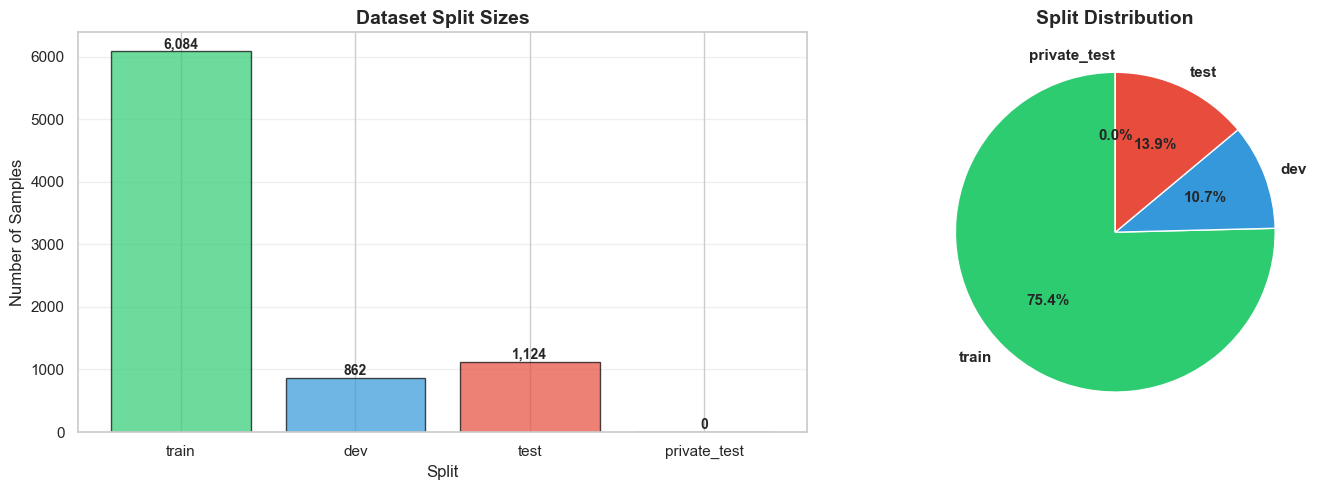


Total samples across all splits: 8,070
  train       : 6,084 (75.4%)
  dev         : 862 (10.7%)
  test        : 1,124 (13.9%)
  private_test: 0 (0.0%)


In [11]:
# Visualization 1: Split Sizes Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Get data
splits = list(split_stats.keys())
sizes = [split_stats[s]['total_samples'] for s in splits]
colors = [split_colors.get(s, '#95a5a6') for s in splits]

# Bar chart
axes[0].bar(splits, sizes, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_title('Dataset Split Sizes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_xlabel('Split', fontsize=12)
for i, (split, size) in enumerate(zip(splits, sizes)):
    axes[0].text(i, size + 50, f'{size:,}', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(sizes, labels=splits, colors=colors, autopct='%1.1f%%',
           startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Split Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(project_path('processed_data', 'viz_split_sizes.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print summary
total = sum(sizes)
print(f"\nTotal samples across all splits: {total:,}")
for split, size in zip(splits, sizes):
    pct = (size / total * 100) if total > 0 else 0
    print(f"  {split:12s}: {size:,} ({pct:.1f}%)")

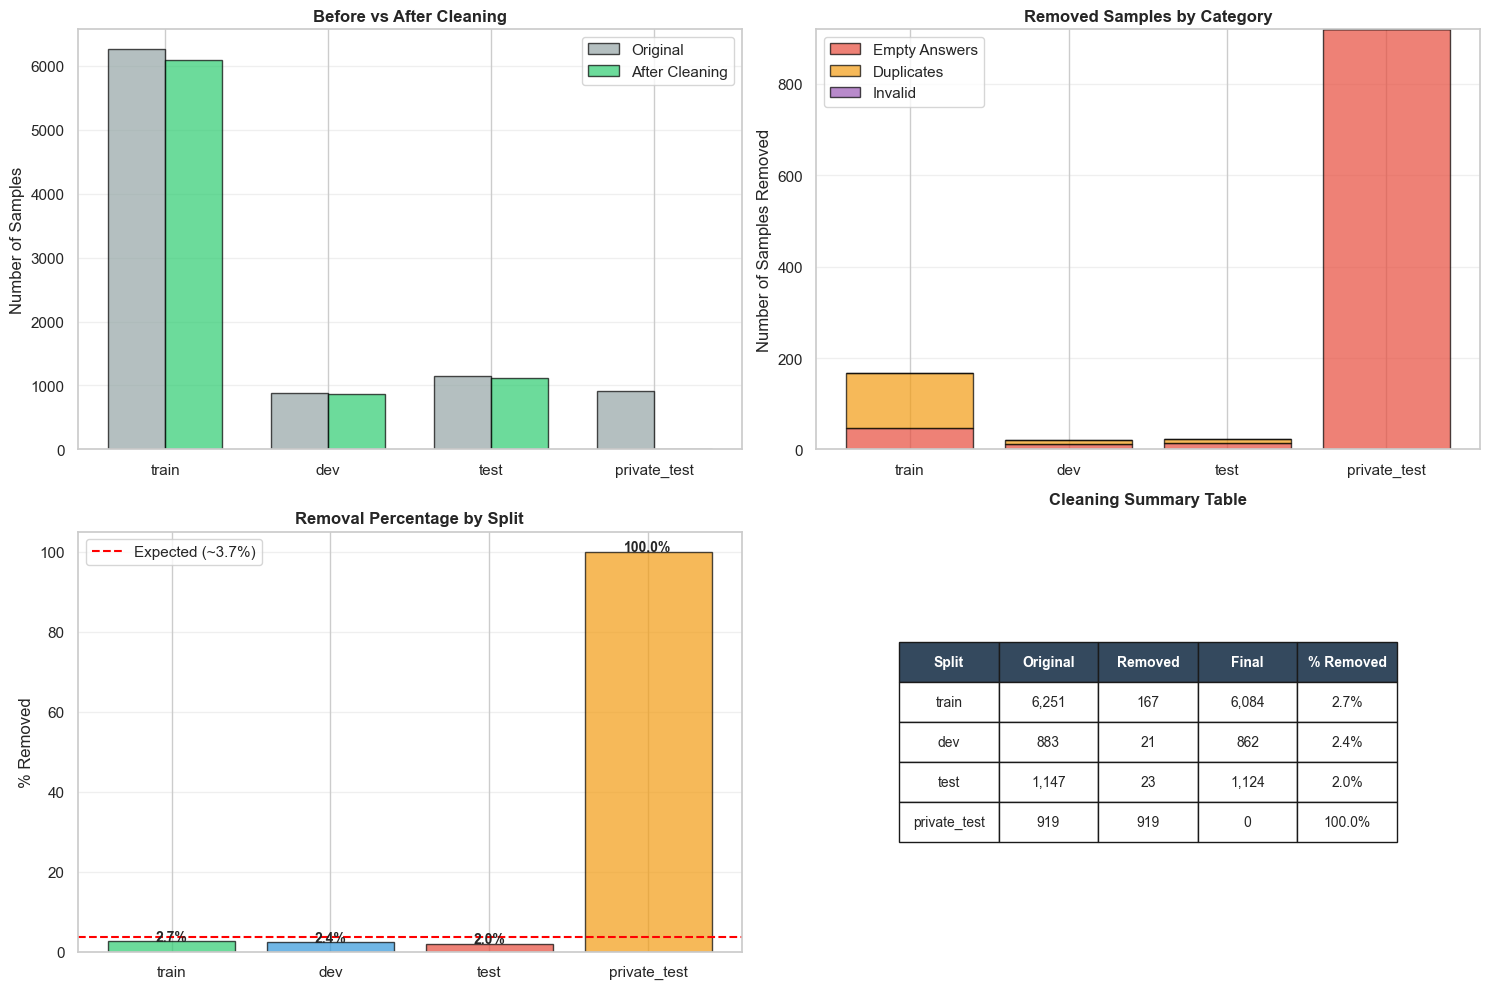

In [12]:
# Visualization 2: Data Cleaning Impact
if ENABLE_DATA_CLEANING and all_cleaning_stats:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    splits = list(all_cleaning_stats.keys())
    
    # 1. Before vs After comparison
    original_counts = [all_cleaning_stats[s]['original'] for s in splits]
    final_counts = [all_cleaning_stats[s]['final'] for s in splits]
    
    x = np.arange(len(splits))
    width = 0.35
    
    axes[0, 0].bar(x - width/2, original_counts, width, label='Original',
                   color='#95a5a6', alpha=0.7, edgecolor='black')
    axes[0, 0].bar(x + width/2, final_counts, width, label='After Cleaning',
                   color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[0, 0].set_title('Before vs After Cleaning', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Number of Samples')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(splits)
    axes[0, 0].legend()
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # 2. Removed samples breakdown
    removed_data = []
    for s in splits:
        stats = all_cleaning_stats[s]
        removed_data.append([
            stats.get('empty_answers', 0),
            stats.get('duplicates', 0),
            stats.get('invalid', 0)
        ])
    
    removed_data = np.array(removed_data).T
    categories = ['Empty Answers', 'Duplicates', 'Invalid']
    colors_removed = ['#e74c3c', '#f39c12', '#9b59b6']
    
    bottom = np.zeros(len(splits))
    for i, (category, color) in enumerate(zip(categories, colors_removed)):
        axes[0, 1].bar(splits, removed_data[i], bottom=bottom, label=category,
                       color=color, alpha=0.7, edgecolor='black')
        bottom += removed_data[i]
    
    axes[0, 1].set_title('Removed Samples by Category', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Number of Samples Removed')
    axes[0, 1].legend()
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # 3. Removal percentage
    removal_pcts = [all_cleaning_stats[s].get('removed_pct', 0) for s in splits]
    colors_pct = [split_colors.get(s, '#95a5a6') for s in splits]
    
    axes[1, 0].bar(splits, removal_pcts, color=colors_pct, alpha=0.7, edgecolor='black')
    axes[1, 0].set_title('Removal Percentage by Split', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('% Removed')
    axes[1, 0].axhline(y=3.7, color='red', linestyle='--', label='Expected (~3.7%)')
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)
    for i, pct in enumerate(removal_pcts):
        axes[1, 0].text(i, pct + 0.1, f'{pct:.1f}%', ha='center', fontweight='bold')
    
    # 4. Summary table
    axes[1, 1].axis('off')
    table_data = []
    for s in splits:
        stats = all_cleaning_stats[s]
        table_data.append([
            s,
            f"{stats['original']:,}",
            f"{stats['removed']:,}",
            f"{stats['final']:,}",
            f"{stats.get('removed_pct', 0):.1f}%"
        ])
    
    table = axes[1, 1].table(cellText=table_data,
                             colLabels=['Split', 'Original', 'Removed', 'Final', '% Removed'],
                             cellLoc='center',
                             loc='center',
                             colWidths=[0.15, 0.15, 0.15, 0.15, 0.15])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Style header
    for i in range(5):
        table[(0, i)].set_facecolor('#34495e')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    axes[1, 1].set_title('Cleaning Summary Table', fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig(project_path('processed_data', 'viz_cleaning_impact.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
else:
    print("Cleaning visualization skipped (ENABLE_DATA_CLEANING=False)")

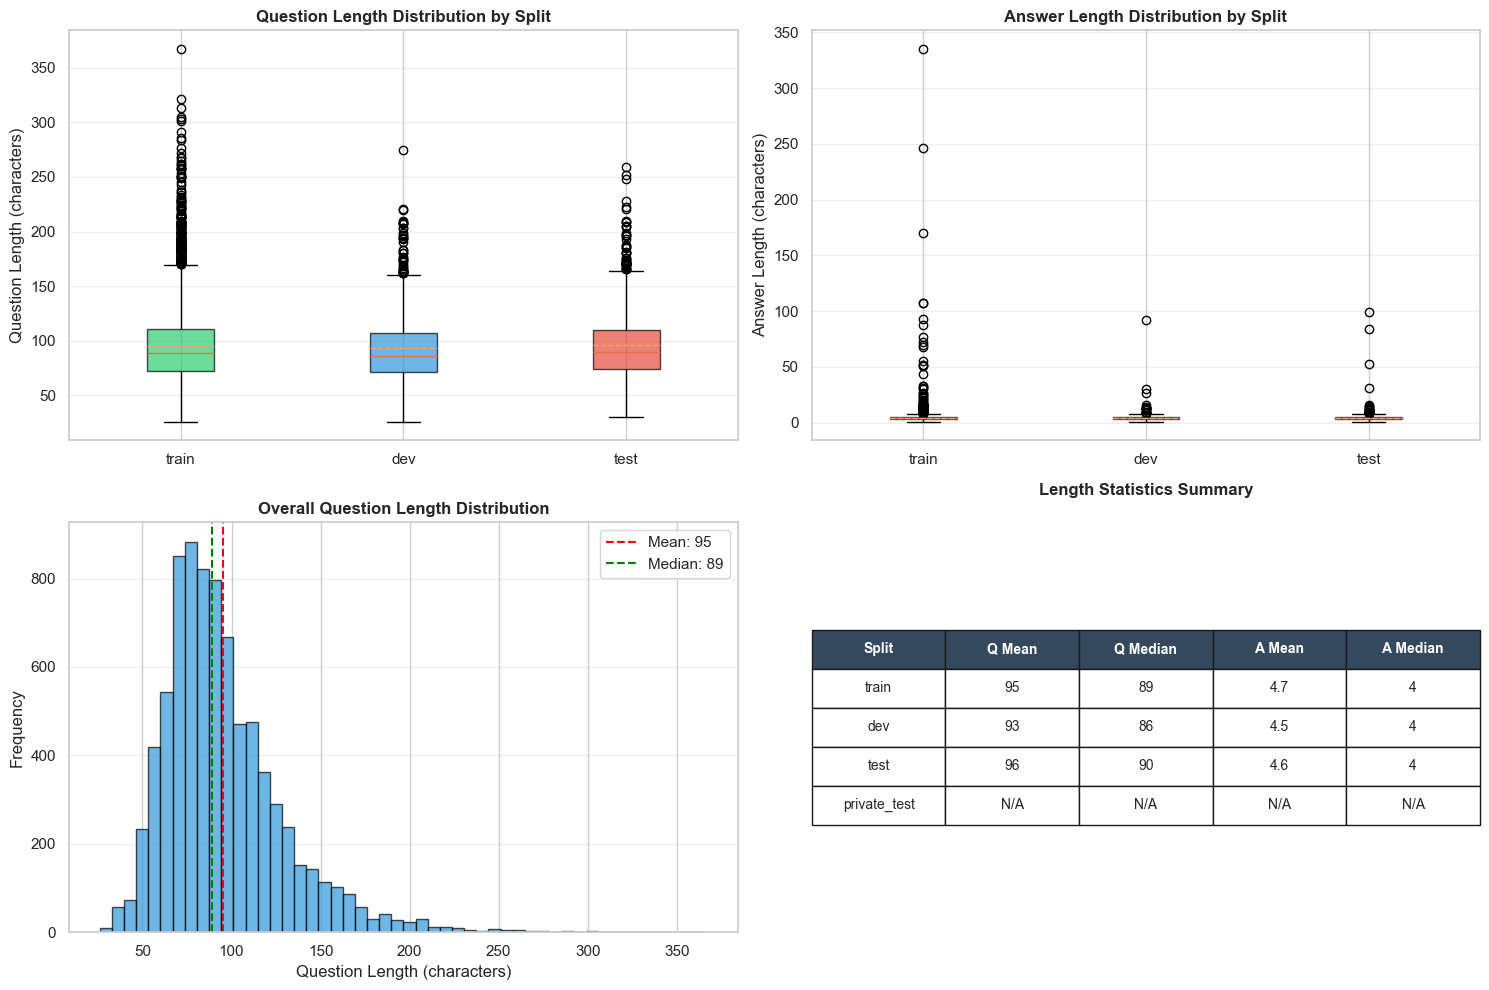


Question Length Statistics:
  Mean: 95 characters
  Median: 89 characters
  Min: 26, Max: 367


In [13]:
# Visualization 3: Question and Answer Length Distributions
if not split_stats:
    print("⚠ No split statistics available. Skipping visualization.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    splits = list(split_stats.keys())
    
    # 1. Question lengths by split (box plot)
    question_data = [split_stats[s]['question_lengths'] for s in splits if split_stats[s]['question_lengths']]
    valid_splits_q = [s for s in splits if split_stats[s]['question_lengths']]
    colors_list = [split_colors.get(s, '#95a5a6') for s in valid_splits_q]
    
    if question_data:
        bp1 = axes[0, 0].boxplot(question_data, tick_labels=valid_splits_q, patch_artist=True,
                                  showmeans=True, meanline=True)
        for patch, color in zip(bp1['boxes'], colors_list):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
    axes[0, 0].set_title('Question Length Distribution by Split', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Question Length (characters)')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # 2. Answer lengths by split (box plot)
    answer_data = [split_stats[s]['answer_lengths'] for s in splits if split_stats[s]['answer_lengths']]
    valid_splits_a = [s for s in splits if split_stats[s]['answer_lengths']]
    colors_list_a = [split_colors.get(s, '#95a5a6') for s in valid_splits_a]
    
    if answer_data:
        bp2 = axes[0, 1].boxplot(answer_data, tick_labels=valid_splits_a, patch_artist=True,
                                  showmeans=True, meanline=True)
        for patch, color in zip(bp2['boxes'], colors_list_a):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
    axes[0, 1].set_title('Answer Length Distribution by Split', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Answer Length (characters)')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # 3. Question lengths histogram (combined)
    all_q_lengths = []
    for s in splits:
        all_q_lengths.extend(split_stats[s]['question_lengths'])
    
    if all_q_lengths:
        axes[1, 0].hist(all_q_lengths, bins=50, color='#3498db', alpha=0.7, edgecolor='black')
        axes[1, 0].axvline(np.mean(all_q_lengths), color='red', linestyle='--',
                           label=f'Mean: {np.mean(all_q_lengths):.0f}')
        axes[1, 0].axvline(np.median(all_q_lengths), color='green', linestyle='--',
                           label=f'Median: {np.median(all_q_lengths):.0f}')
        axes[1, 0].legend()
    axes[1, 0].set_title('Overall Question Length Distribution', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Question Length (characters)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # 4. Statistics table
    axes[1, 1].axis('off')
    table_data = []
    for s in splits:
        q_lens = split_stats[s]['question_lengths']
        a_lens = split_stats[s]['answer_lengths']
        if q_lens and a_lens:
            table_data.append([
                s,
                f"{np.mean(q_lens):.0f}",
                f"{np.median(q_lens):.0f}",
                f"{np.mean(a_lens):.1f}",
                f"{np.median(a_lens):.0f}"
            ])
        else:
            table_data.append([s, 'N/A', 'N/A', 'N/A', 'N/A'])
    
    if table_data:
        table = axes[1, 1].table(cellText=table_data,
                                 colLabels=['Split', 'Q Mean', 'Q Median', 'A Mean', 'A Median'],
                                 cellLoc='center',
                                 loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2)
        
        for i in range(5):
            table[(0, i)].set_facecolor('#34495e')
            table[(0, i)].set_text_props(weight='bold', color='white')
    
    axes[1, 1].set_title('Length Statistics Summary', fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig(project_path('processed_data', 'viz_lengths.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    if all_q_lengths:
        print("\nQuestion Length Statistics:")
        print(f"  Mean: {np.mean(all_q_lengths):.0f} characters")
        print(f"  Median: {np.median(all_q_lengths):.0f} characters")
        print(f"  Min: {np.min(all_q_lengths):.0f}, Max: {np.max(all_q_lengths):.0f}")

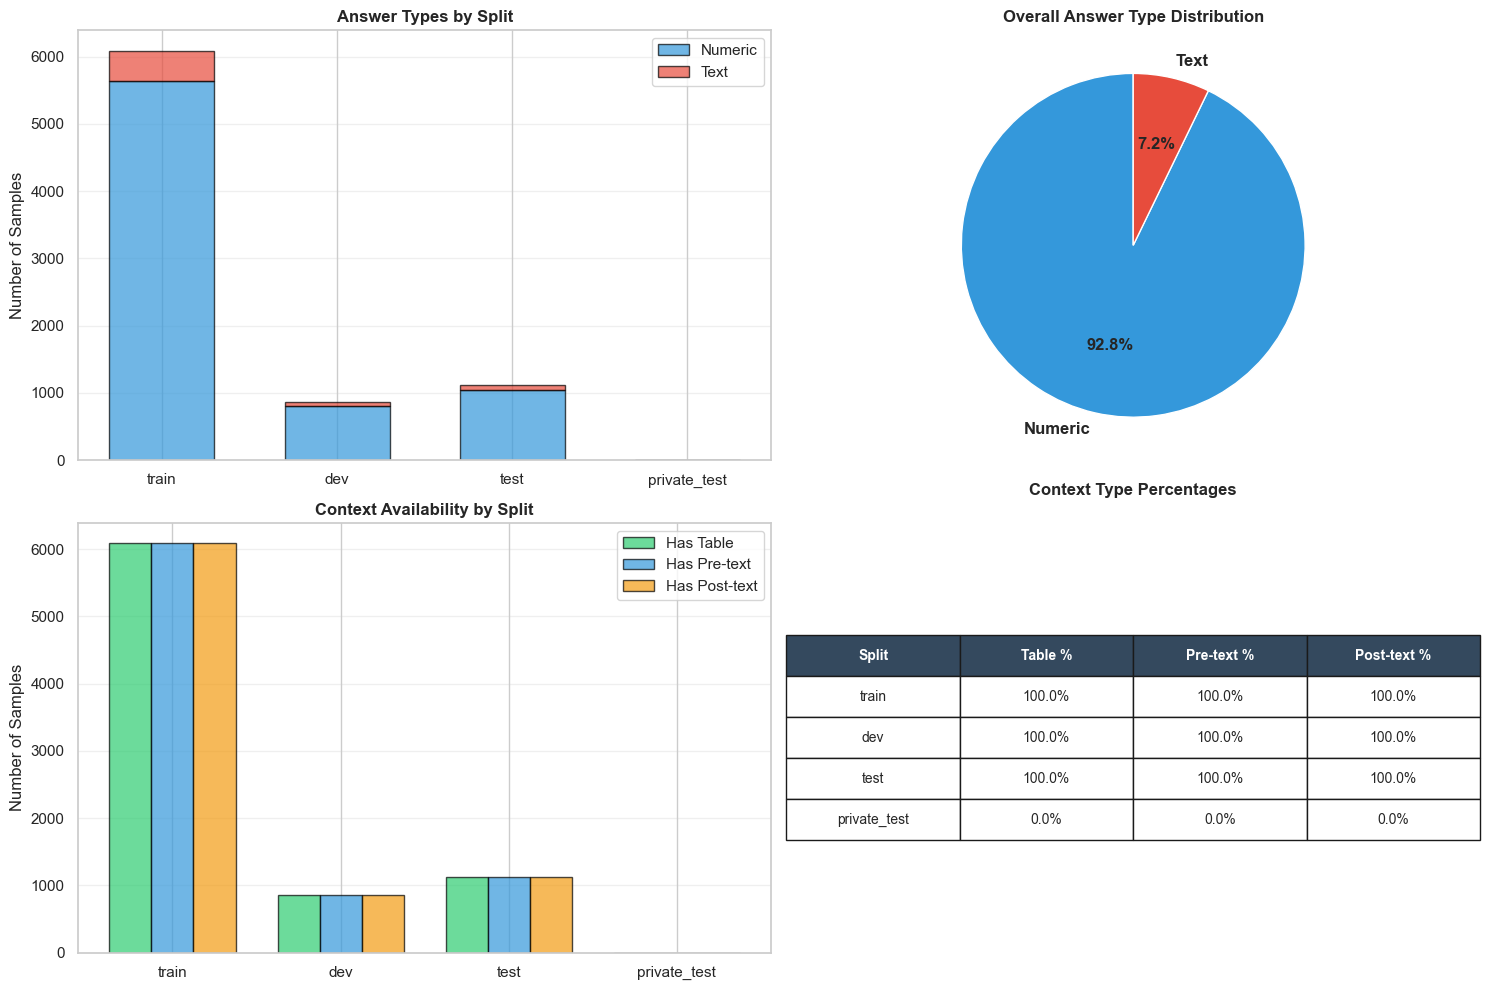


Answer Type Distribution:
  Numeric: 7,489 (92.8%)
  Text: 581 (7.2%)


In [14]:
# Visualization 4: Answer Types and Context Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

splits = list(split_stats.keys())

# 1. Answer types by split (stacked bar)
numeric_counts = [split_stats[s]['numeric_answers'] for s in splits]
text_counts = [split_stats[s]['text_answers'] for s in splits]

x = np.arange(len(splits))
width = 0.6

axes[0, 0].bar(x, numeric_counts, width, label='Numeric',
               color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].bar(x, text_counts, width, bottom=numeric_counts, label='Text',
               color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Answer Types by Split', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Samples')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(splits)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Overall answer type distribution (pie)
total_numeric = sum(numeric_counts)
total_text = sum(text_counts)

axes[0, 1].pie([total_numeric, total_text],
               labels=['Numeric', 'Text'],
               colors=['#3498db', '#e74c3c'],
               autopct='%1.1f%%',
               startangle=90,
               textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[0, 1].set_title('Overall Answer Type Distribution', fontsize=12, fontweight='bold')

# 3. Context availability by split
has_table = [split_stats[s]['has_table'] for s in splits]
has_pre = [split_stats[s]['has_pre_text'] for s in splits]
has_post = [split_stats[s]['has_post_text'] for s in splits]

x = np.arange(len(splits))
width = 0.25

axes[1, 0].bar(x - width, has_table, width, label='Has Table',
               color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1, 0].bar(x, has_pre, width, label='Has Pre-text',
               color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].bar(x + width, has_post, width, label='Has Post-text',
               color='#f39c12', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Context Availability by Split', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Number of Samples')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(splits)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Context type percentages
axes[1, 1].axis('off')
table_data = []
for s in splits:
    total = split_stats[s]['total_samples']
    table_pct = (split_stats[s]['has_table'] / total * 100) if total > 0 else 0
    pre_pct = (split_stats[s]['has_pre_text'] / total * 100) if total > 0 else 0
    post_pct = (split_stats[s]['has_post_text'] / total * 100) if total > 0 else 0
    
    table_data.append([
        s,
        f"{table_pct:.1f}%",
        f"{pre_pct:.1f}%",
        f"{post_pct:.1f}%"
    ])

table = axes[1, 1].table(cellText=table_data,
                         colLabels=['Split', 'Table %', 'Pre-text %', 'Post-text %'],
                         cellLoc='center',
                         loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

for i in range(4):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

axes[1, 1].set_title('Context Type Percentages', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(project_path('processed_data', 'viz_answer_context.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAnswer Type Distribution:")
print(f"  Numeric: {total_numeric:,} ({total_numeric/(total_numeric+total_text)*100:.1f}%)")
print(f"  Text: {total_text:,} ({total_text/(total_numeric+total_text)*100:.1f}%)")

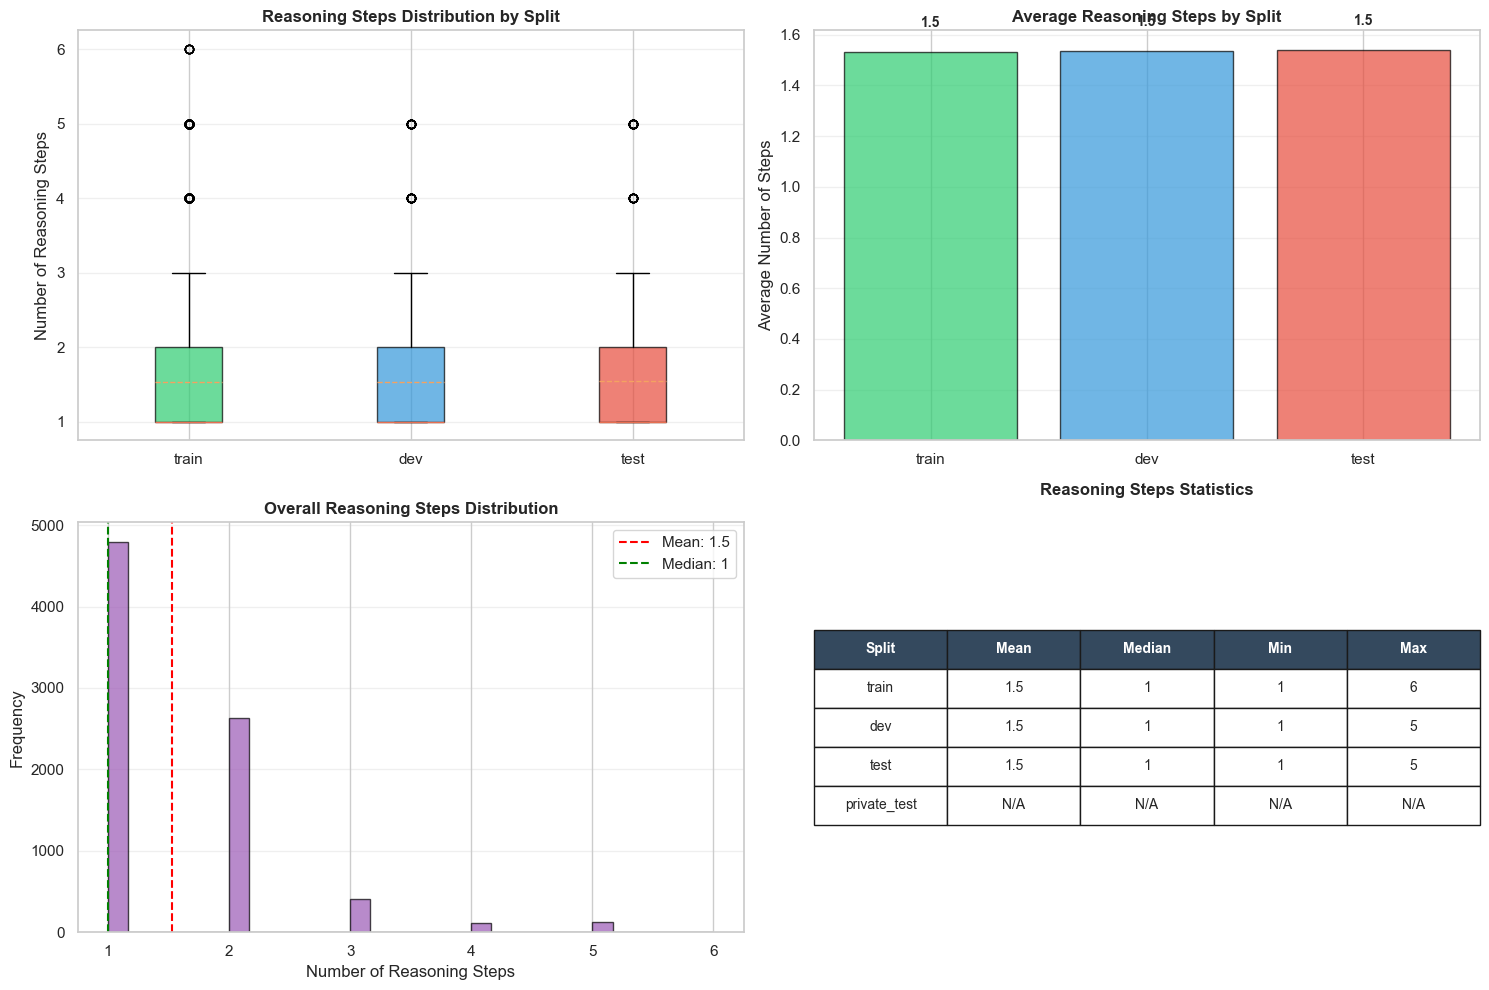


Reasoning Steps Statistics:
  Mean: 1.5 steps
  Median: 1 steps
  Min: 1, Max: 6


In [15]:
# Visualization 5: Reasoning Steps Analysis
if not split_stats:
    print("⚠ No split statistics available. Skipping visualization.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    splits = list(split_stats.keys())
    
    # 1. Reasoning steps distribution by split (box plot)
    reasoning_data = [split_stats[s]['reasoning_steps'] for s in splits if split_stats[s]['reasoning_steps']]
    valid_splits = [s for s in splits if split_stats[s]['reasoning_steps']]
    colors_list = [split_colors.get(s, '#95a5a6') for s in valid_splits]
    
    if reasoning_data:
        bp = axes[0, 0].boxplot(reasoning_data, tick_labels=valid_splits, patch_artist=True,
                                showmeans=True, meanline=True)
        for patch, color in zip(bp['boxes'], colors_list):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
    axes[0, 0].set_title('Reasoning Steps Distribution by Split', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Number of Reasoning Steps')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # 2. Average reasoning steps per split (bar chart)
    avg_steps = []
    valid_splits_avg = []
    for s in splits:
        if split_stats[s]['reasoning_steps']:
            avg_steps.append(np.mean(split_stats[s]['reasoning_steps']))
            valid_splits_avg.append(s)
    
    colors_list_avg = [split_colors.get(s, '#95a5a6') for s in valid_splits_avg]
    
    if avg_steps:
        axes[0, 1].bar(valid_splits_avg, avg_steps, color=colors_list_avg, alpha=0.7, edgecolor='black')
        for i, val in enumerate(avg_steps):
            axes[0, 1].text(i, val + 0.1, f'{val:.1f}', ha='center', fontweight='bold')
    axes[0, 1].set_title('Average Reasoning Steps by Split', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Average Number of Steps')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # 3. Overall reasoning steps histogram
    all_steps = []
    for s in splits:
        all_steps.extend(split_stats[s]['reasoning_steps'])
    
    if all_steps:
        axes[1, 0].hist(all_steps, bins=30, color='#9b59b6', alpha=0.7, edgecolor='black')
        axes[1, 0].axvline(np.mean(all_steps), color='red', linestyle='--',
                           label=f'Mean: {np.mean(all_steps):.1f}')
        axes[1, 0].axvline(np.median(all_steps), color='green', linestyle='--',
                           label=f'Median: {np.median(all_steps):.0f}')
        axes[1, 0].legend()
    axes[1, 0].set_title('Overall Reasoning Steps Distribution', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Number of Reasoning Steps')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # 4. Statistics table
    axes[1, 1].axis('off')
    table_data = []
    for s in splits:
        steps = split_stats[s]['reasoning_steps']
        if steps:
            table_data.append([
                s,
                f"{np.mean(steps):.1f}",
                f"{np.median(steps):.0f}",
                f"{np.min(steps):.0f}",
                f"{np.max(steps):.0f}"
            ])
        else:
            table_data.append([s, 'N/A', 'N/A', 'N/A', 'N/A'])
    
    if table_data:
        table = axes[1, 1].table(cellText=table_data,
                                 colLabels=['Split', 'Mean', 'Median', 'Min', 'Max'],
                                 cellLoc='center',
                                 loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2)
        
        for i in range(5):
            table[(0, i)].set_facecolor('#34495e')
            table[(0, i)].set_text_props(weight='bold', color='white')
    
    axes[1, 1].set_title('Reasoning Steps Statistics', fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig(project_path('processed_data', 'viz_reasoning_steps.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    if all_steps:
        print("\nReasoning Steps Statistics:")
        print(f"  Mean: {np.mean(all_steps):.1f} steps")
        print(f"  Median: {np.median(all_steps):.0f} steps")
        print(f"  Min: {np.min(all_steps):.0f}, Max: {np.max(all_steps):.0f}")

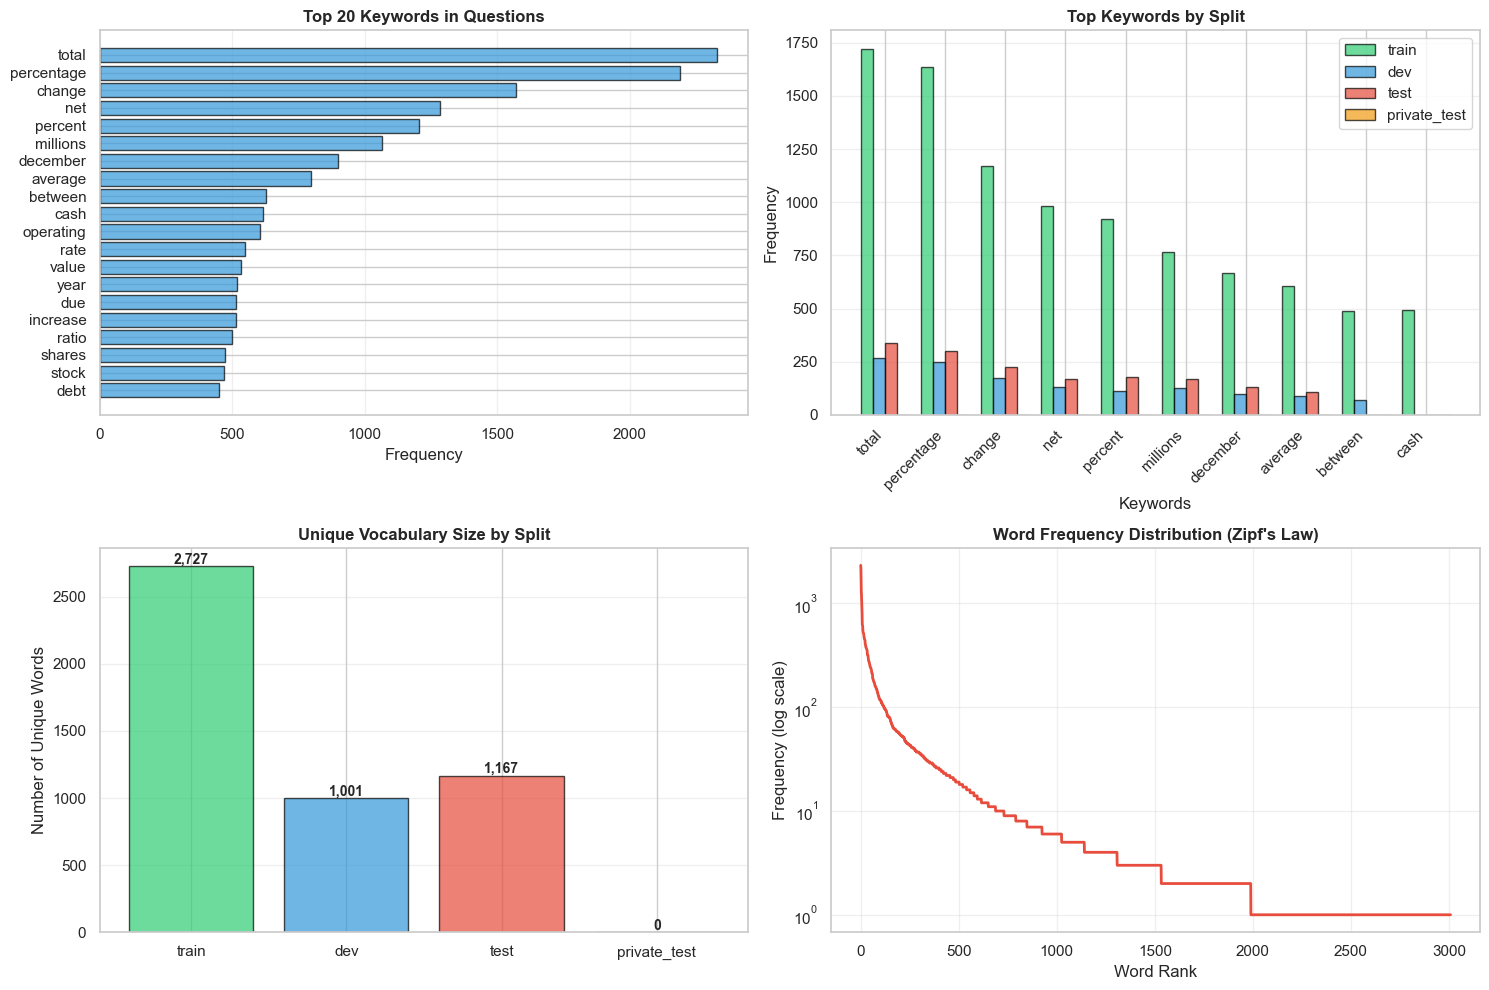


Vocabulary Statistics:
  Total unique words: 3,009
  Total word occurrences: 62,611

Top 5 keywords:
    total: 2,330
    percentage: 2,188
    change: 1,569
    net: 1,285
    percent: 1,206


In [16]:
# Visualization 6: Question Keywords Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Define stop words
stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
              'of', 'with', 'by', 'from', 'as', 'is', 'was', 'are', 'were', 'be',
              'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will',
              'would', 'should', 'could', 'may', 'might', 'must', 'can', 'what',
              'which', 'who', 'when', 'where', 'why', 'how', 'that', 'this', 'these',
              'those', 'it', 'its', 'they', 'them', 'their'}

# Collect all words from all splits
all_words = []
for s in split_stats:
    words = [w for w in split_stats[s]['question_words']
             if w not in stop_words and len(w) > 2]
    all_words.extend(words)

word_freq = Counter(all_words)
top_20_words = word_freq.most_common(20)

# 1. Top 20 keywords (horizontal bar)
words, counts = zip(*top_20_words)
y_pos = np.arange(len(words))

axes[0, 0].barh(y_pos, counts, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].set_yticks(y_pos)
axes[0, 0].set_yticklabels(words)
axes[0, 0].invert_yaxis()
axes[0, 0].set_title('Top 20 Keywords in Questions', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Frequency')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Top 10 per split comparison
split_top_words = {}
for s in split_stats:
    words = [w for w in split_stats[s]['question_words']
             if w not in stop_words and len(w) > 2]
    freq = Counter(words)
    split_top_words[s] = freq.most_common(10)

# Get unique top words across all splits
all_top_words = set()
for s in split_top_words:
    all_top_words.update([w for w, _ in split_top_words[s]])

# Plot top 10 most common across all
top_10_overall = word_freq.most_common(10)
words_10, _ = zip(*top_10_overall)

x = np.arange(len(words_10))
width = 0.2

for i, s in enumerate(list(split_stats.keys())[:4]):  # Max 4 splits
    word_dict = dict(split_top_words[s])
    counts_for_words = [word_dict.get(w, 0) for w in words_10]
    offset = (i - 1.5) * width
    axes[0, 1].bar(x + offset, counts_for_words, width,
                   label=s, color=split_colors.get(s, '#95a5a6'),
                   alpha=0.7, edgecolor='black')

axes[0, 1].set_title('Top Keywords by Split', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Keywords')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(words_10, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Vocabulary size by split
vocab_sizes = []
for s in split_stats:
    words = [w for w in split_stats[s]['question_words']
             if w not in stop_words and len(w) > 2]
    vocab_sizes.append(len(set(words)))

splits = list(split_stats.keys())
colors_list = [split_colors.get(s, '#95a5a6') for s in splits]

axes[1, 0].bar(splits, vocab_sizes, color=colors_list, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Unique Vocabulary Size by Split', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Number of Unique Words')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, val in enumerate(vocab_sizes):
    axes[1, 0].text(i, val + 20, f'{val:,}', ha='center', fontweight='bold')

# 4. Word frequency distribution (log scale)
frequencies = sorted(word_freq.values(), reverse=True)
axes[1, 1].plot(range(len(frequencies)), frequencies, color='#e74c3c', linewidth=2)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Word Frequency Distribution (Zipf\'s Law)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Word Rank')
axes[1, 1].set_ylabel('Frequency (log scale)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(project_path('processed_data', 'viz_keywords.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVocabulary Statistics:")
print(f"  Total unique words: {len(word_freq):,}")
print(f"  Total word occurrences: {sum(word_freq.values()):,}")
print(f"\nTop 5 keywords:")
for word, count in top_20_words[:5]:
    print(f"    {word}: {count:,}")

/var/folders/ft/w1m9fjt15kq_n08blxds8tn80000gn/T/ipykernel_79660/4056234751.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


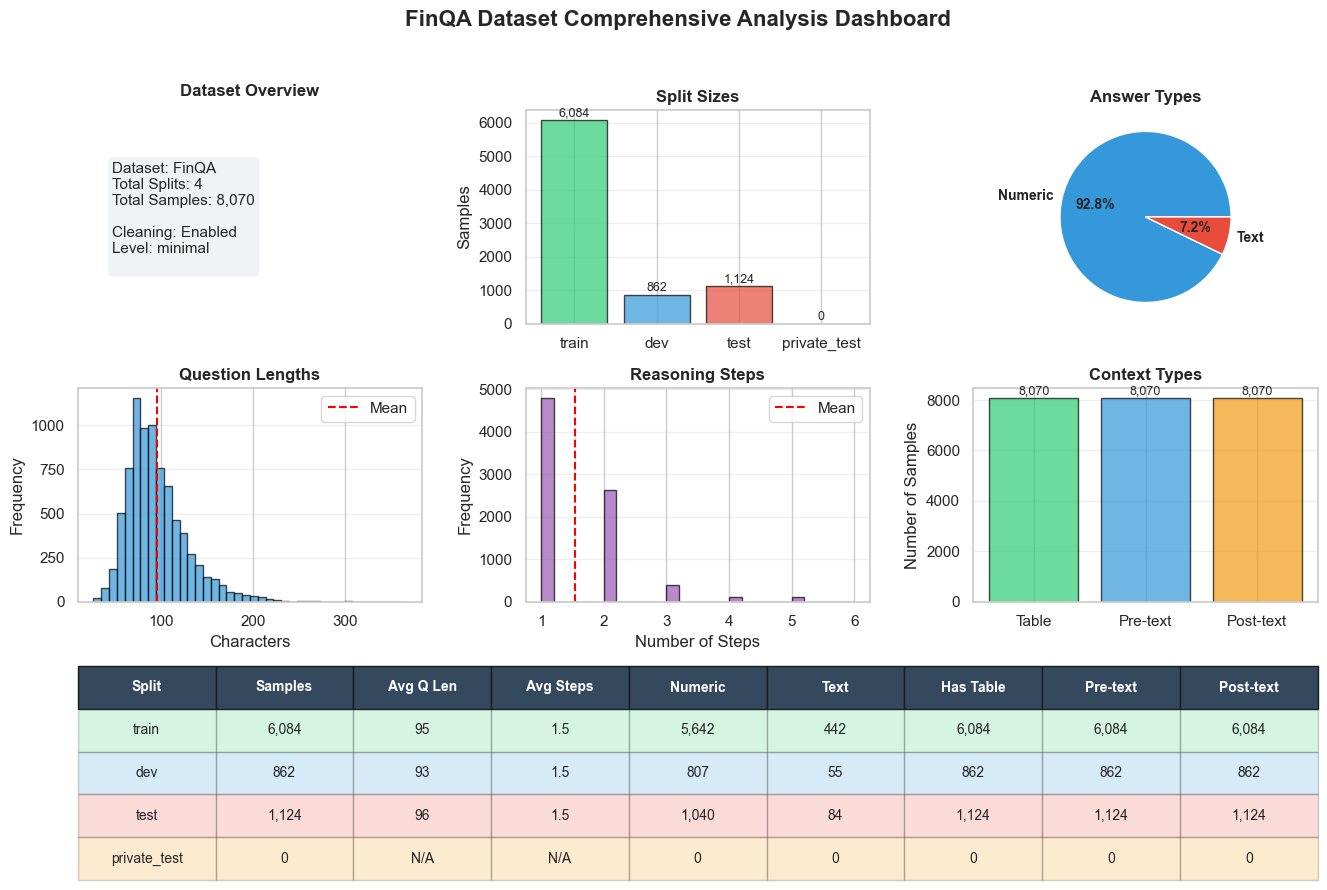


ALL VISUALIZATIONS COMPLETE

Generated visualizations:
  1. viz_split_sizes.png
  2. viz_cleaning_impact.png
  3. viz_lengths.png
  4. viz_answer_context.png
  5. viz_reasoning_steps.png
  6. viz_keywords.png
  7. viz_summary_dashboard.png

Location: /Users/uzmanarfan/Documents/FinGEO-SLM/processed_data


In [17]:
# Visualization 7: Comprehensive Summary Dashboard
if not split_stats:
    print("⚠ No split statistics available. Skipping visualization.")
else:
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # Title
    fig.suptitle('FinQA Dataset Comprehensive Analysis Dashboard', fontsize=16, fontweight='bold', y=0.98)
    
    splits = list(split_stats.keys())
    
    # 1. Dataset Overview (top left)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.axis('off')
    total_samples = sum([split_stats[s]['total_samples'] for s in splits])
    overview_text = f"""Dataset: FinQA
Total Splits: {len(splits)}
Total Samples: {total_samples:,}

Cleaning: {'Enabled' if ENABLE_DATA_CLEANING else 'Disabled'}
Level: {CLEANING_LEVEL if ENABLE_DATA_CLEANING else 'N/A'}
"""
    ax1.text(0.1, 0.5, overview_text, fontsize=11, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))
    ax1.set_title('Dataset Overview', fontsize=12, fontweight='bold', pad=10)
    
    # 2. Split sizes (top middle)
    ax2 = fig.add_subplot(gs[0, 1])
    sizes = [split_stats[s]['total_samples'] for s in splits]
    colors_list = [split_colors.get(s, '#95a5a6') for s in splits]
    ax2.bar(splits, sizes, color=colors_list, alpha=0.7, edgecolor='black')
    ax2.set_title('Split Sizes', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Samples')
    ax2.grid(axis='y', alpha=0.3)
    for i, val in enumerate(sizes):
        ax2.text(i, val + max(sizes)*0.02, f'{val:,}', ha='center', fontsize=9)
    
    # 3. Answer types (top right)
    ax3 = fig.add_subplot(gs[0, 2])
    total_numeric = sum([split_stats[s]['numeric_answers'] for s in splits])
    total_text = sum([split_stats[s]['text_answers'] for s in splits])
    if total_numeric > 0 or total_text > 0:
        ax3.pie([total_numeric, total_text], labels=['Numeric', 'Text'],
                colors=['#3498db', '#e74c3c'], autopct='%1.1f%%',
                textprops={'fontsize': 10, 'fontweight': 'bold'})
    ax3.set_title('Answer Types', fontsize=12, fontweight='bold')
    
    # 4. Question lengths (middle left)
    ax4 = fig.add_subplot(gs[1, 0])
    all_q_lengths = []
    for s in splits:
        all_q_lengths.extend(split_stats[s]['question_lengths'])
    if all_q_lengths:
        ax4.hist(all_q_lengths, bins=40, color='#3498db', alpha=0.7, edgecolor='black')
        ax4.axvline(np.mean(all_q_lengths), color='red', linestyle='--', label='Mean')
        ax4.legend()
    ax4.set_title('Question Lengths', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Characters')
    ax4.set_ylabel('Frequency')
    ax4.grid(axis='y', alpha=0.3)
    
    # 5. Reasoning steps (middle middle)
    ax5 = fig.add_subplot(gs[1, 1])
    all_steps = []
    for s in splits:
        all_steps.extend(split_stats[s]['reasoning_steps'])
    if all_steps:
        ax5.hist(all_steps, bins=25, color='#9b59b6', alpha=0.7, edgecolor='black')
        ax5.axvline(np.mean(all_steps), color='red', linestyle='--', label='Mean')
        ax5.legend()
    ax5.set_title('Reasoning Steps', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Number of Steps')
    ax5.set_ylabel('Frequency')
    ax5.grid(axis='y', alpha=0.3)
    
    # 6. Context availability (middle right)
    ax6 = fig.add_subplot(gs[1, 2])
    context_types = ['Table', 'Pre-text', 'Post-text']
    context_totals = [
        sum([split_stats[s]['has_table'] for s in splits]),
        sum([split_stats[s]['has_pre_text'] for s in splits]),
        sum([split_stats[s]['has_post_text'] for s in splits])
    ]
    ax6.bar(context_types, context_totals,
            color=['#2ecc71', '#3498db', '#f39c12'],
            alpha=0.7, edgecolor='black')
    ax6.set_title('Context Types', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Number of Samples')
    ax6.grid(axis='y', alpha=0.3)
    max_context = max(context_totals) if context_totals else 1
    for i, val in enumerate(context_totals):
        ax6.text(i, val + max_context*0.02, f'{val:,}', ha='center', fontsize=9)
    
    # 7. Statistics table (bottom, spanning all columns)
    ax7 = fig.add_subplot(gs[2, :])
    ax7.axis('off')
    
    table_data = []
    for s in splits:
        stats = split_stats[s]
        q_lens = stats['question_lengths']
        r_steps = stats['reasoning_steps']
        table_data.append([
            s,
            f"{stats['total_samples']:,}",
            f"{np.mean(q_lens):.0f}" if q_lens else 'N/A',
            f"{np.mean(r_steps):.1f}" if r_steps else 'N/A',
            f"{stats['numeric_answers']:,}",
            f"{stats['text_answers']:,}",
            f"{stats['has_table']:,}",
            f"{stats['has_pre_text']:,}",
            f"{stats['has_post_text']:,}"
        ])
    
    table = ax7.table(cellText=table_data,
                      colLabels=['Split', 'Samples', 'Avg Q Len', 'Avg Steps',
                                'Numeric', 'Text', 'Has Table', 'Pre-text', 'Post-text'],
                      cellLoc='center',
                      loc='center',
                      bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.5)
    
    # Style header
    for i in range(9):
        table[(0, i)].set_facecolor('#34495e')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Color rows by split
    for i, s in enumerate(splits):
        color = split_colors.get(s, '#95a5a6')
        for j in range(9):
            table[(i+1, j)].set_facecolor(color)
            table[(i+1, j)].set_alpha(0.2)
    
    plt.tight_layout()
    plt.savefig(project_path('processed_data', 'viz_summary_dashboard.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*80)
    print("ALL VISUALIZATIONS COMPLETE")
    print("="*80)
    print("\nGenerated visualizations:")
    viz_files = [
        'viz_split_sizes.png',
        'viz_cleaning_impact.png',
        'viz_lengths.png',
        'viz_answer_context.png',
        'viz_reasoning_steps.png',
        'viz_keywords.png',
        'viz_summary_dashboard.png'
    ]
    for i, f in enumerate(viz_files, 1):
        print(f"  {i}. {f}")
    print(f"\nLocation: {project_path('processed_data')}")
    print("="*80)

## Prompt Formatting Functions

Utilities for parsing tables and formatting CoT prompts.

In [18]:
def format_table_to_markdown(table_data):
    """Converts raw 2D array financial tables into structurally faithful Markdown with NaN handling."""
    if not table_data or len(table_data) == 0:
        return ""
    try:
        headers = table_data[0]
        rows = table_data[1:]
        df = pd.DataFrame(rows, columns=headers)
        # Improvement: Fill empty/dash values with 0 or N/A for consistency
        df = df.replace(['', '-', 'n/a', 'None'], '0')
        return df.to_markdown(index=False)
    except Exception:
        return str(table_data)

def format_cot_prompt(example, tokenizer=None, max_tokens=3500):
    """Formats FinQA into a strict CoT prompt with smart truncation."""
    pre_text = " ".join(example.get("pre_text", []))
    post_text = " ".join(example.get("post_text", []))
    table_context = format_table_to_markdown(example.get("table", []))
    question = example.get("question", "")
    answer = example.get("answer", "")
    exe_list = example.get("exe_list", [])

    # Validation: Skip junk data
    if not question or len(question) < 5:
        return {"formatted_prompt": None}

    reasoning_steps = " -> ".join([
        f"{s.get('op', '')}({s.get('arg1', '')}, {s.get('arg2', '')}) = {s.get('res', '')}"
        for s in exe_list
    ]) if isinstance(exe_list, list) and exe_list and isinstance(exe_list[0], dict) else str(exe_list)

    instruction = "You are a highly accurate financial AI. Use the context and table to answer step-by-step."

    def build_p(pre, post):
        return f"[INST] {instruction}\nContext:\n{pre}\n{post}\n\nFinancial Table:\n{table_context}\n\nQuestion: {question}\n[/INST]\nLet's think step by step.\nReasoning: {reasoning_steps}\nFinal Answer: {answer}"

    full_prompt = build_p(pre_text, post_text)

    # Improvement: Smart Truncation
    if tokenizer and len(tokenizer.encode(full_prompt)) > max_tokens:
        # Priority: Table and Question are kept; pre/post text are truncated
        pre_text = pre_text[:500] + "..."
        post_text = post_text[:500] + "..."
        full_prompt = build_p(pre_text, post_text)

    return {"formatted_prompt": full_prompt}

## Apply Formatting

Apply CoT formatting to the dataset with smart truncation.

In [19]:
print("\n" + "="*80)
print("APPLYING COT FORMATTING TO ALL SPLITS")
print("="*80)

tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

# Storage for formatted datasets
all_formatted_datasets = {}
all_formatted_raw_datasets = {}  # For raw versions

# Process each split
for split_name in finqa_splits:
    if split_name not in all_cleaned_datasets:
        print(f"\n⚠ Skipping {split_name} (not loaded)")
        continue
    
    print(f"\n--- Formatting {split_name} split ---")
    
    # Convert cleaned data to Dataset
    cleaned_list = all_cleaned_datasets[split_name]
    dataset_cleaned = Dataset.from_list(cleaned_list)
    print(f"  Cleaned samples: {len(dataset_cleaned):,}")
    
    # Apply CoT formatting
    formatted = dataset_cleaned.map(
        lambda x: format_cot_prompt(x, tokenizer=tokenizer),
        desc=f"Formatting {split_name}"
    )
    
    # Filter out None results
    formatted = formatted.filter(lambda x: x['formatted_prompt'] is not None)
    print(f"  Final formatted: {len(formatted):,}")
    
    all_formatted_datasets[split_name] = formatted
    
    # Also format raw version if requested
    if SAVE_RAW_VERSION and split_name in all_raw_datasets:
        print(f"  Formatting raw version...")
        raw_list = []
        for item in all_raw_datasets[split_name]:
            qa = item.get('qa', {})
            raw_list.append({
                'question': qa.get('question', ''),
                'answer': str(qa.get('answer', '')),
                'pre_text': item.get('pre_text', []),
                'post_text': item.get('post_text', []),
                'table': item.get('table', []),
                'exe_list': qa.get('exe_list', qa.get('steps', [])),
            })
        dataset_raw = Dataset.from_list(raw_list)
        formatted_raw = dataset_raw.map(
            lambda x: format_cot_prompt(x, tokenizer=tokenizer),
            desc=f"Formatting {split_name} (raw)"
        )
        formatted_raw = formatted_raw.filter(lambda x: x['formatted_prompt'] is not None)
        all_formatted_raw_datasets[split_name] = formatted_raw
        print(f"  Raw formatted: {len(formatted_raw):,}")

print("\n" + "="*80)
print("FORMATTING COMPLETE")
print("="*80)
for split_name in all_formatted_datasets:
    print(f"  {split_name:12s}: {len(all_formatted_datasets[split_name]):,} samples")
print("="*80)


APPLYING COT FORMATTING TO ALL SPLITS

--- Formatting train split ---
  Cleaned samples: 6,084


Filter: 100%|██████████| 6084/6084 [00:00<00:00, 15960.45 examples/s]


  Final formatted: 6,084
  Formatting raw version...


Filter: 100%|██████████| 6251/6251 [00:00<00:00, 24874.64 examples/s]


  Raw formatted: 6,251

--- Formatting dev split ---
  Cleaned samples: 862


...

  Final formatted: 1,124
  Formatting raw version...


Filter: 100%|██████████| 1147/1147 [00:00<00:00, 28772.27 examples/s]


  Raw formatted: 1,147

--- Formatting private_test split ---
  Cleaned samples: 0
  Final formatted: 0
  Formatting raw version...


Filter: 100%|██████████| 919/919 [00:00<00:00, 34519.01 examples/s]

  Raw formatted: 919

FORMATTING COMPLETE
  train       : 6,084 samples
  dev         : 862 samples
  test        : 1,124 samples
  private_test: 0 samples


## Visualizations

Comprehensive visual analysis of the dataset characteristics.

### 1. Dataset Size Comparison

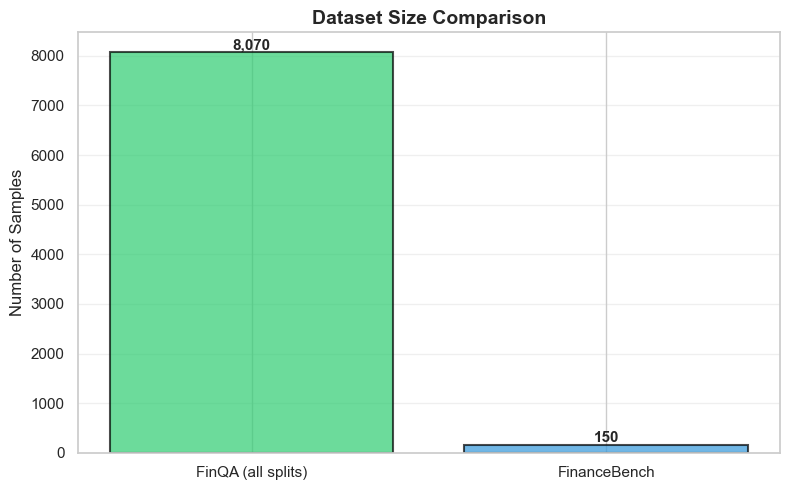


Dataset Comparison:
  FinQA (all splits): 8,070 samples
  FinanceBench: 150 samples
  FinQA is 53.8x larger than FinanceBench


In [20]:
# Dataset Size Comparison
if financebench_dataset and split_stats:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Calculate total FinQA samples across all splits
    total_finqa = sum([split_stats[s]['total_samples'] for s in split_stats])
    
    datasets = ['FinQA (all splits)', 'FinanceBench']
    sizes = [total_finqa, len(financebench_dataset)]
    
    colors = ['#2ecc71', '#3498db']
    bars = ax.bar(datasets, sizes, color=colors, edgecolor='black', linewidth=1.5, alpha=0.7)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax.set_ylabel('Number of Samples', fontsize=12)
    ax.set_title('Dataset Size Comparison', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(project_path('processed_data', 'viz_dataset_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print comparison
    print(f"\nDataset Comparison:")
    print(f"  FinQA (all splits): {total_finqa:,} samples")
    print(f"  FinanceBench: {len(financebench_dataset):,} samples")
    print(f"  FinQA is {total_finqa/len(financebench_dataset):.1f}x larger than FinanceBench")
else:
    print("⚠ Skipping dataset comparison - data not loaded")

### 2. Question Length Distribution

NameError: name 'question_lengths' is not defined

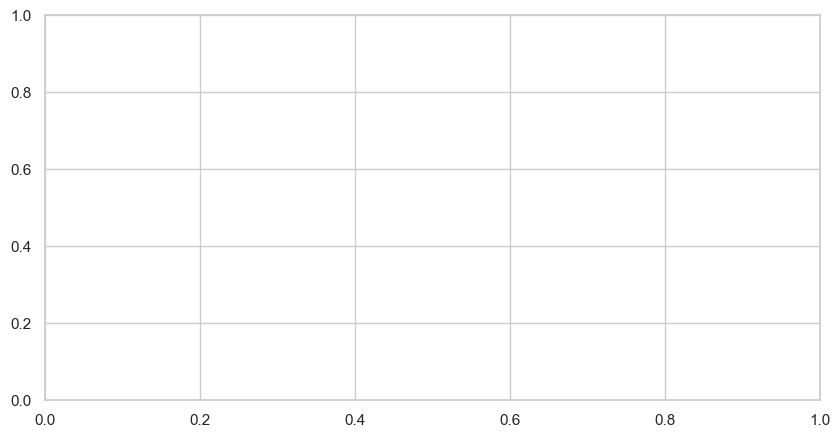

In [21]:
# Extract all question lengths from split_stats
question_lengths = []
if split_stats:
    for s in split_stats:
        question_lengths.extend(split_stats[s]['question_lengths'])

if not question_lengths:
    print("No question length data available")
else:
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.hist(question_lengths, bins=50, color=COLORS[0], edgecolor='black', alpha=0.7)

    # Add statistics
    mean_len = np.mean(question_lengths)
    median_len = np.median(question_lengths)
    ax.axvline(mean_len, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.1f}')
    ax.axvline(median_len, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_len:.1f}')

    ax.set_xlabel('Question Length (characters)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title('Distribution of Question Lengths', fontsize=13, fontweight='bold', pad=15)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Question Length Statistics:")
    print(f"  Min: {min(question_lengths)} | Max: {max(question_lengths)}")
    print(f"  Mean: {mean_len:.1f} | Median: {median_len:.1f}")
    print(f"  Std Dev: {np.std(question_lengths):.1f}")


### 3. Answer Length Distribution

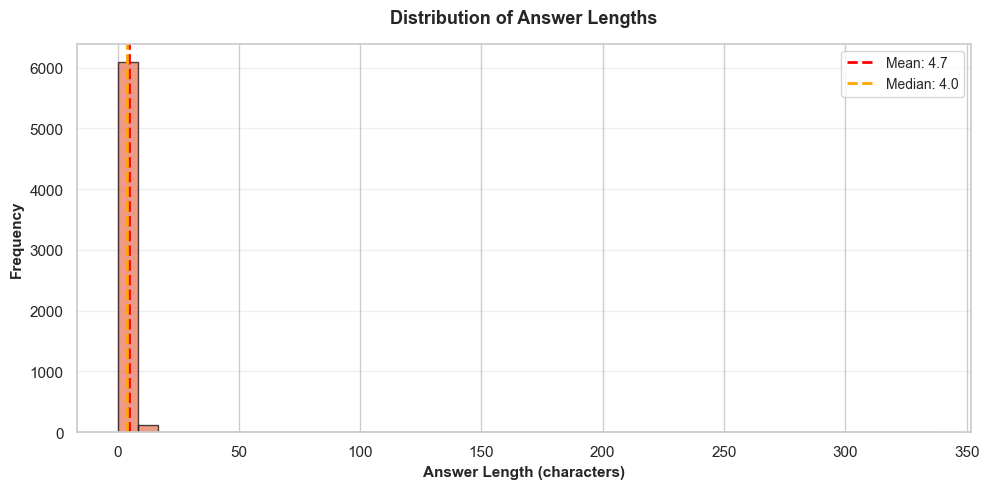

Answer Length Statistics:
  Min: 0 | Max: 335
  Mean: 4.7 | Median: 4.0
  Std Dev: 7.6


In [ ]:
# Extract all answer lengths from split_stats
answer_lengths = []
if split_stats:
    for s in split_stats:
        answer_lengths.extend(split_stats[s]['answer_lengths'])

if not answer_lengths:
    print("No answer length data available")
else:
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.hist(answer_lengths, bins=40, color=COLORS[1], edgecolor='black', alpha=0.7)

    # Add statistics
    mean_len = np.mean(answer_lengths)
    median_len = np.median(answer_lengths)
    ax.axvline(mean_len, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.1f}')
    ax.axvline(median_len, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_len:.1f}')

    ax.set_xlabel('Answer Length (characters)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title('Distribution of Answer Lengths', fontsize=13, fontweight='bold', pad=15)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Answer Length Statistics:")
    print(f"  Min: {min(answer_lengths)} | Max: {max(answer_lengths)}")
    print(f"  Mean: {mean_len:.1f} | Median: {median_len:.1f}")
    print(f"  Std Dev: {np.std(answer_lengths):.1f}")


### 4. Table Size Visualization (Rows × Columns)

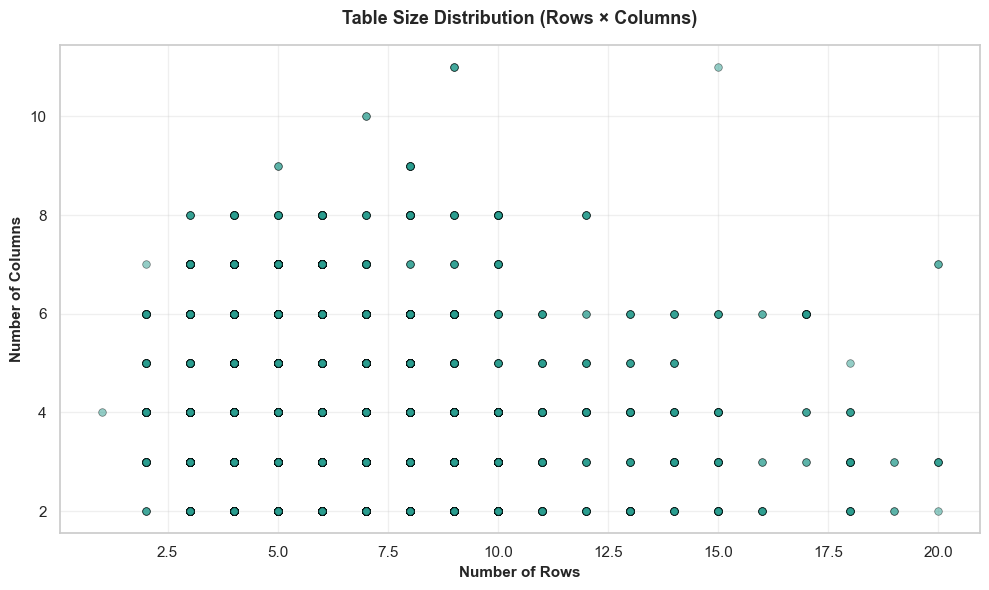

Table Size Statistics:
  Tables with data: 6,251 (100.0%)
  Average rows: 6.3 | Average columns: 3.8
  Max rows: 20 | Max columns: 11


In [ ]:
# Extract table sizes from split_stats
table_sizes = []
if split_stats:
    for s in split_stats:
        rows = split_stats[s].get('table_rows', [])
        cols = split_stats[s].get('table_cols', [])
        for r, c in zip(rows, cols):
            table_sizes.append((r, c))

if not table_sizes or all(size[0] == 0 for size in table_sizes):
    print("No table size data available")
else:
    fig, ax = plt.subplots(figsize=(10, 6))

    rows = [size[0] for size in table_sizes if size[0] > 0]
    cols = [size[1] for size in table_sizes if size[0] > 0]

    # Create scatter plot with alpha for overlapping points
    scatter = ax.scatter(cols, rows, alpha=0.3, c=COLORS[0], edgecolors='black', linewidth=0.5, s=50)

    ax.set_xlabel('Number of Columns', fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of Rows', fontsize=11, fontweight='bold')
    ax.set_title('Table Dimensions in Dataset', fontsize=13, fontweight='bold', pad=15)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Table Statistics:")
    print(f"  Total tables analyzed: {len(rows)}")
    print(f"  Rows - Min: {min(rows)}, Max: {max(rows)}, Mean: {np.mean(rows):.1f}")
    print(f"  Cols - Min: {min(cols)}, Max: {max(cols)}, Mean: {np.mean(cols):.1f}")


### 5. Reasoning Steps Count Distribution

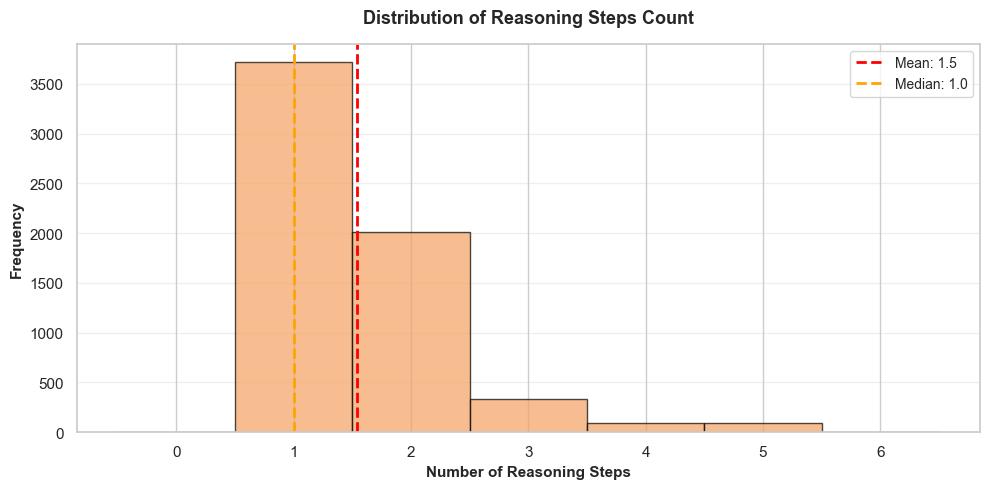

Reasoning Steps Statistics:
  Min: 1 | Max: 6
  Mean: 1.54 | Median: 1.0
  Std Dev: 0.80


In [ ]:
# Extract reasoning steps from split_stats
reasoning_steps_count = []
if split_stats:
    for s in split_stats:
        reasoning_steps_count.extend(split_stats[s].get('reasoning_steps', []))

if not reasoning_steps_count:
    print("No reasoning steps data available")
else:
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.hist(reasoning_steps_count, bins=range(0, max(reasoning_steps_count)+2), 
            color=COLORS[2], edgecolor='black', alpha=0.7, align='left')

    # Add statistics
    mean_steps = np.mean(reasoning_steps_count)
    median_steps = np.median(reasoning_steps_count)
    ax.axvline(mean_steps, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_steps:.1f}')
    ax.axvline(median_steps, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_steps:.1f}')

    ax.set_xlabel('Number of Reasoning Steps', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title('Distribution of Reasoning Complexity', fontsize=13, fontweight='bold', pad=15)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Reasoning Steps Statistics:")
    print(f"  Min: {min(reasoning_steps_count)} | Max: {max(reasoning_steps_count)}")
    print(f"  Mean: {mean_steps:.1f} | Median: {median_steps:.1f}")


### 6. Pre/Post Text Length Comparison

/var/folders/ft/w1m9fjt15kq_n08blxds8tn80000gn/T/ipykernel_33598/1252428990.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,


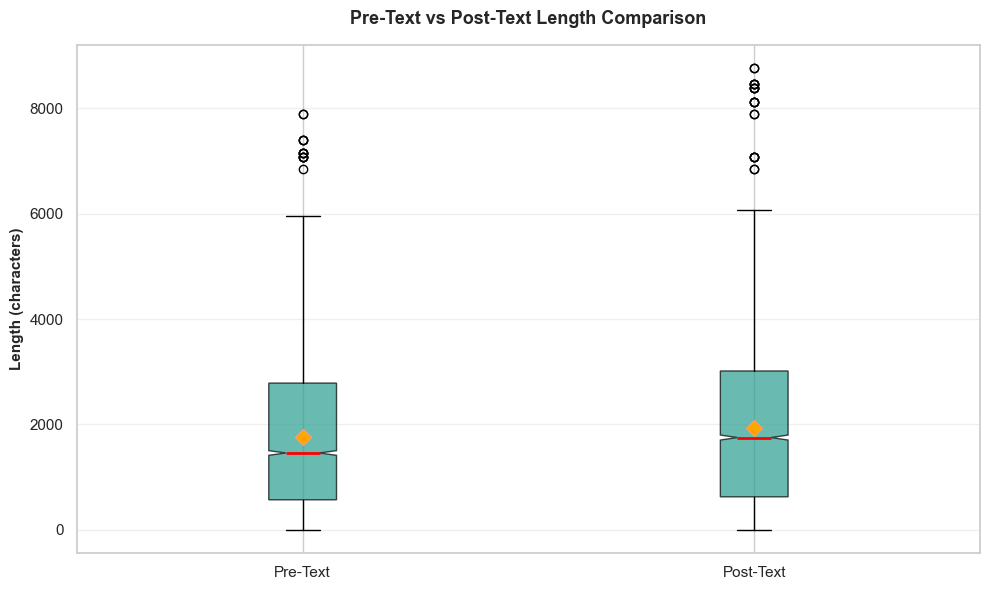

Pre-Text Statistics:
  Mean: 1770.1 | Median: 1458.0

Post-Text Statistics:
  Mean: 1925.3 | Median: 1751.0


In [ ]:
# Extract context lengths from split_stats
pre_text_lengths = []
post_text_lengths = []
if split_stats:
    for s in split_stats:
        pre_text_lengths.extend(split_stats[s].get('pre_text_lengths', []))
        post_text_lengths.extend(split_stats[s].get('post_text_lengths', []))

if not pre_text_lengths and not post_text_lengths:
    print("No context length data available")
else:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Prepare data for box plots
    data_to_plot = [pre_text_lengths, post_text_lengths]
    labels = ['Pre-Text', 'Post-Text']

    bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)

    # Customize colors
    colors = [COLORS[0], COLORS[1]]
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_ylabel('Context Length (characters)', fontsize=11, fontweight='bold')
    ax.set_title('Context Text Lengths Distribution', fontsize=13, fontweight='bold', pad=15)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Context Length Statistics:")
    print(f"  Pre-Text - Mean: {np.mean(pre_text_lengths):.1f}, Median: {np.median(pre_text_lengths):.1f}")
    print(f"  Post-Text - Mean: {np.mean(post_text_lengths):.1f}, Median: {np.median(post_text_lengths):.1f}")


### 7. Top Question Words

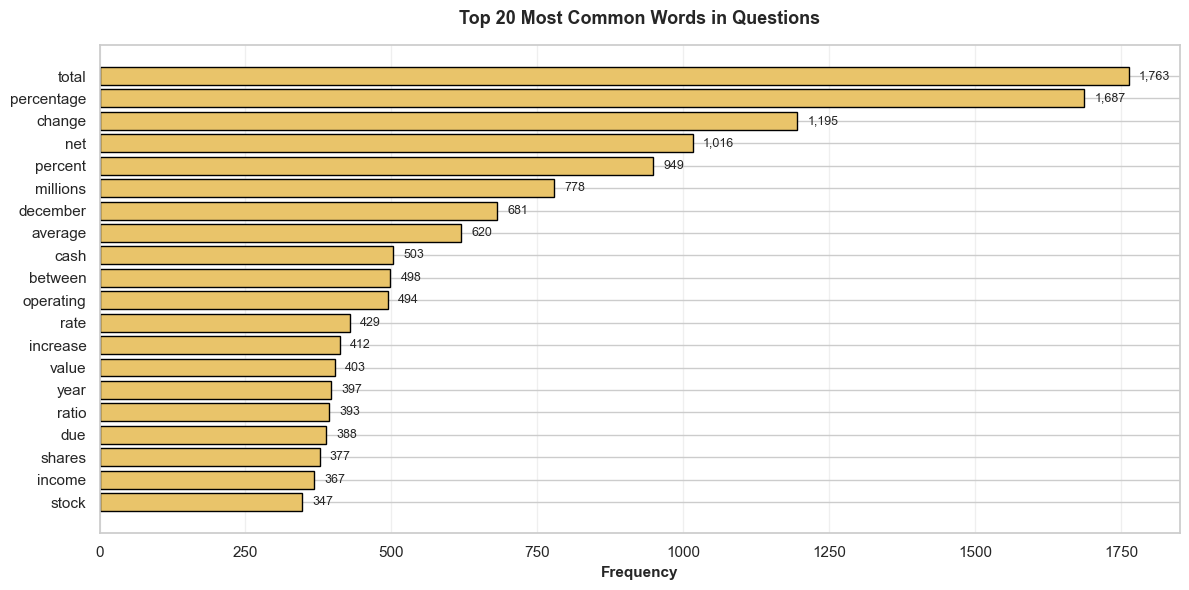


Top 5 most common words:
  total: 1,763
  percentage: 1,687
  change: 1,195
  net: 1,016
  percent: 949


In [ ]:
# Extract and count question words from split_stats
from collections import Counter

all_question_words = []
if split_stats:
    for s in split_stats:
        all_question_words.extend(split_stats[s].get('question_words', []))

if not all_question_words:
    print("No question word data available")
else:
    word_counts = Counter(all_question_words)
    top_words = word_counts.most_common(20)

    fig, ax = plt.subplots(figsize=(12, 6))

    words, counts = zip(*top_words)
    y_pos = np.arange(len(words))

    bars = ax.barh(y_pos, counts, color=COLORS[3], edgecolor='black', linewidth=1)

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2., 
                f'{int(width)}', va='center', fontweight='bold', fontsize=9)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(words)
    ax.invert_yaxis()
    ax.set_xlabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title('Top 20 Most Common Words in Questions', fontsize=13, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()


### 8. Answer Type Distribution (Numeric vs Text)

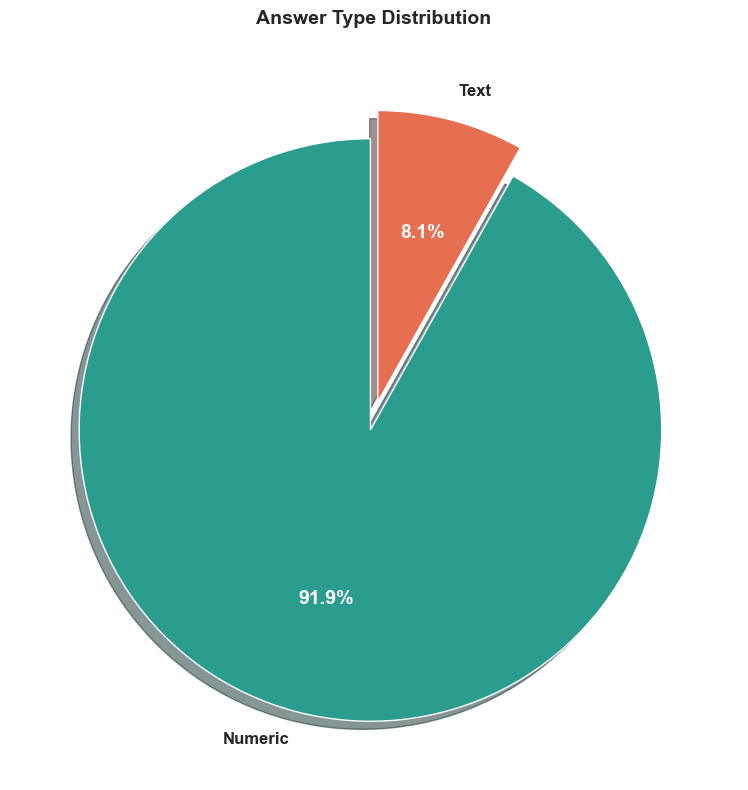

Answer Type Breakdown:
  Numeric: 5,742 (91.9%)
  Text: 509 (8.1%)


In [ ]:
# Extract answer type information from split_stats
from collections import Counter

answer_types = []
if split_stats:
    for s in split_stats:
        numeric = split_stats[s].get('numeric_answers', 0)
        text = split_stats[s].get('text_answers', 0)
        answer_types.extend(['Numeric'] * numeric)
        answer_types.extend(['Text'] * text)

if not answer_types:
    print("No answer type data available")
else:
    fig, ax = plt.subplots(figsize=(8, 8))

    type_counts = Counter(answer_types)
    labels = list(type_counts.keys())
    sizes = list(type_counts.values())
    colors_pie = [COLORS[0], COLORS[1]]

    wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%',
                                       colors=colors_pie[:len(labels)], startangle=90,
                                       explode=[0.02] * len(labels),
                                       textprops={'fontsize': 11, 'fontweight': 'bold'})

    ax.set_title('Answer Type Distribution', fontsize=13, fontweight='bold', pad=15)

    plt.tight_layout()
    plt.show()

    print(f"Answer Type Breakdown:")
    for label, size in zip(labels, sizes):
        print(f"  {label}: {size} ({size/sum(sizes)*100:.1f}%)")


### 9. Enhanced Token Length Visualization with Percentiles

Computing token lengths for formatted prompts...


Computing token lengths: 100%|██████████| 2000/2000 [00:00<00:00, 4708.87 examples/s]


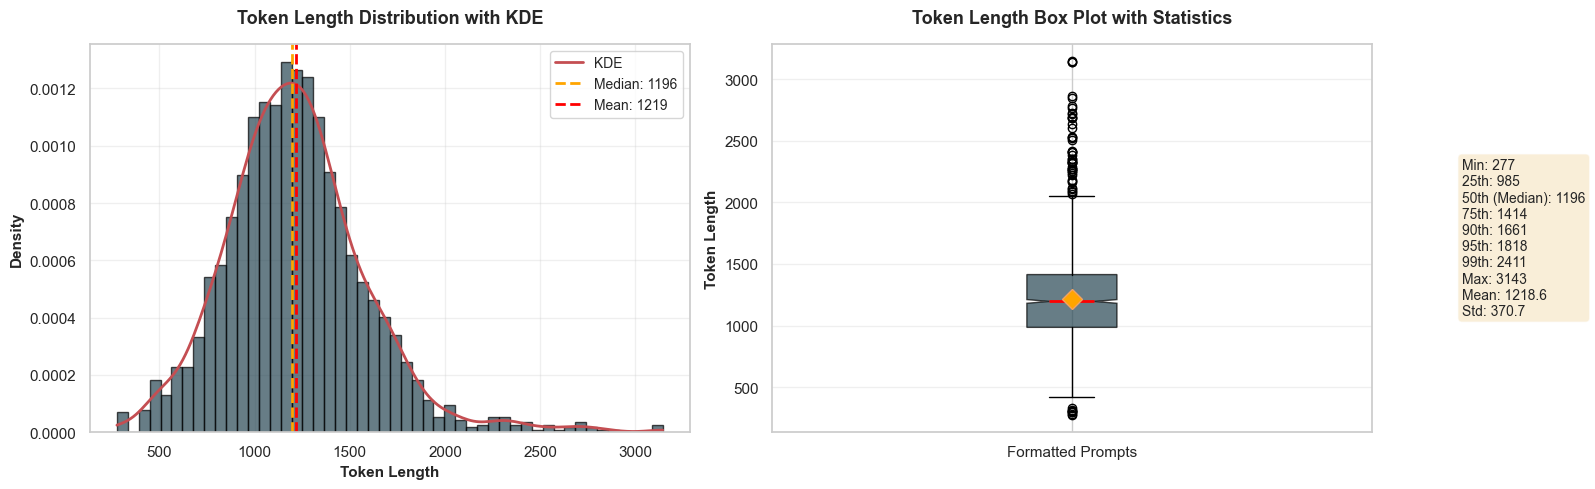


Token Length Statistics (Sample of 2,000):
  Min: 277 | Max: 3143
  Mean: 1218.64 | Median: 1196
  Std Dev: 370.67

Percentiles:
  25th: 985 | 75th: 1414
  90th: 1661 | 95th: 1818 | 99th: 2411


In [ ]:
try:
    print("Computing token lengths for formatted prompts...")
    
    # Combine all formatted datasets for analysis
    from datasets import concatenate_datasets
    if all_formatted_datasets:
        finqa_cot_dataset = concatenate_datasets(list(all_formatted_datasets.values()))
    else:
        raise ValueError("No formatted datasets available")
    
    sample_size = min(2000, len(finqa_cot_dataset))
    eda_sample = finqa_cot_dataset.select(range(sample_size))

    def add_token_length(batch):
        tokenized = tokenizer(batch["formatted_prompt"], add_special_tokens=False)
        return {"token_length": [len(ids) for ids in tokenized["input_ids"]]}

    eda_with_len = eda_sample.map(add_token_length, batched=True, desc="Computing token lengths")
    lengths = eda_with_len["token_length"]

    # Calculate percentiles
    p25 = np.percentile(lengths, 25)
    p50 = np.percentile(lengths, 50)
    p75 = np.percentile(lengths, 75)
    p90 = np.percentile(lengths, 90)
    p95 = np.percentile(lengths, 95)
    p99 = np.percentile(lengths, 99)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Histogram with KDE
    ax1.hist(lengths, bins=50, color=COLORS[4], edgecolor='black', alpha=0.7, density=True)
    
    # Add KDE
    from scipy import stats
    density = stats.gaussian_kde(lengths)
    x_range = np.linspace(min(lengths), max(lengths), 200)
    ax1.plot(x_range, density(x_range), 'r-', linewidth=2, label='KDE')
    
    ax1.axvline(p50, color='orange', linestyle='--', linewidth=2, label=f'Median: {p50:.0f}')
    ax1.axvline(np.mean(lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(lengths):.0f}')
    
    ax1.set_xlabel('Token Length', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Density', fontsize=11, fontweight='bold')
    ax1.set_title('Token Length Distribution with KDE', fontsize=13, fontweight='bold', pad=15)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Box plot with percentiles
    bp = ax2.boxplot([lengths], vert=True, patch_artist=True, notch=True, showmeans=True,
                      boxprops=dict(facecolor=COLORS[4], alpha=0.7),
                      medianprops=dict(color='red', linewidth=2),
                      meanprops=dict(marker='D', markerfacecolor='orange', markersize=10))
    
    # Add percentile annotations
    percentiles_text = [
        f"Min: {min(lengths)}",
        f"25th: {p25:.0f}",
        f"50th (Median): {p50:.0f}",
        f"75th: {p75:.0f}",
        f"90th: {p90:.0f}",
        f"95th: {p95:.0f}",
        f"99th: {p99:.0f}",
        f"Max: {max(lengths)}",
        f"Mean: {np.mean(lengths):.1f}",
        f"Std: {np.std(lengths):.1f}"
    ]
    
    ax2.text(1.15, 0.5, '\n'.join(percentiles_text), 
             transform=ax2.transAxes, fontsize=10,
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax2.set_ylabel('Token Length', fontsize=11, fontweight='bold')
    ax2.set_title('Token Length Box Plot with Statistics', fontsize=13, fontweight='bold', pad=15)
    ax2.set_xticklabels(['Formatted Prompts'])
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nToken Length Statistics (Sample of {sample_size:,}):")
    print(f"  Min: {min(lengths)} | Max: {max(lengths)}")
    print(f"  Mean: {np.mean(lengths):.2f} | Median: {p50:.0f}")
    print(f"  Std Dev: {np.std(lengths):.2f}")
    print(f"\nPercentiles:")
    print(f"  25th: {p25:.0f} | 75th: {p75:.0f}")
    print(f"  90th: {p90:.0f} | 95th: {p95:.0f} | 99th: {p99:.0f}")
    
except Exception as exc:
    print(f"Token length analysis failed: {exc}")


### 10. Sample Prompt Display with Enhanced Formatting

In [ ]:
import pandas as pd
from IPython.display import display, HTML

# Ensure finqa_cot_dataset is defined
if 'finqa_cot_dataset' not in dir() or finqa_cot_dataset is None:
    from datasets import concatenate_datasets
    if all_formatted_datasets:
        finqa_cot_dataset = concatenate_datasets(list(all_formatted_datasets.values()))
    else:
        raise ValueError("No formatted datasets available")

# Display first 5 samples in a formatted table
display_df = pd.DataFrame(finqa_cot_dataset.select(range(5)))

print("="*100)
print("SAMPLE DATA FROM PREPROCESSED DATASET")
print("="*100)
print(f"\nShowing first 5 rows of {len(finqa_cot_dataset):,} total samples")
print("\nColumns: {}".format(', '.join(display_df.columns)))
print("\n" + "-"*100)

display(display_df[['question', 'answer']].head())

print("\n" + "="*100)
print("DETAILED SAMPLE PROMPT EXAMPLE")
print("="*100)

sample_prompt = finqa_cot_dataset[0]["formatted_prompt"]
sample_question = finqa_cot_dataset[0]["question"]
sample_answer = finqa_cot_dataset[0]["answer"]

print(f"\nQuestion: {sample_question}")
print(f"Answer: {sample_answer}")
print(f"\nToken Count: {len(tokenizer.encode(sample_prompt))}")
print(f"Character Count: {len(sample_prompt)}")

print("\n" + "-"*100)
print("FULL FORMATTED PROMPT:")
print("-"*100 + "\n")

# Format prompt with better wrapping
wrapped_prompt = textwrap.fill(sample_prompt, width=100, 
                               break_long_words=False, 
                               break_on_hyphens=False)
print(wrapped_prompt)

print("\n" + "="*100 + "\n")


SAMPLE DATA FROM PREPROCESSED DATASET

Showing first 5 rows of 6,251 total samples

Columns: pre_text, post_text, table, question, answer, exe_list, formatted_prompt

----------------------------------------------------------------------------------------------------


,question,answer
0,what is the the interest expense in 2009?,380
1,"during the 2012 year , did the equity awards i...",
2,what was the total operating expenses in 2018 ...,41932
3,what percentage of total cash and investments ...,53%
4,what is the growth rate in net revenue in 2008?,-3.2%



DETAILED SAMPLE PROMPT EXAMPLE

Question: what is the the interest expense in 2009?
Answer: 380

Token Count: 1114
Character Count: 4245

----------------------------------------------------------------------------------------------------
FULL FORMATTED PROMPT:
----------------------------------------------------------------------------------------------------

[INST] You are a highly accurate financial AI. Use the context and table to answer step-by-step.
Context: interest rate to a variable interest rate based on the three-month libor plus 2.05% ( 2.05
% ) ( 2.34% ( 2.34 % ) as of october 31 , 2009 ) . if libor changes by 100 basis points , our annual
interest expense would change by $ 3.8 million . foreign currency exposure as more fully described
in note 2i . in the notes to consolidated financial statements contained in item 8 of this annual
report on form 10-k , we regularly hedge our non-u.s . dollar-based exposures by entering into
forward foreign currency exchange contracts .

## Save Processed Data

Save the formatted dataset to disk for use in training.

In [ ]:
import os
from pathlib import Path

print("\n" + "="*80)
print("SAVING DATASETS")
print("="*80)

os.makedirs(project_path("processed_data"), exist_ok=True)

# Determine folder names based on cleaning status
if ENABLE_DATA_CLEANING:
    cleaned_folder = f"finqa_cot_{CLEANING_LEVEL}"  # e.g., finqa_cot_minimal or finqa_cot_full
else:
    cleaned_folder = "finqa_cot_raw"

raw_folder = "finqa_cot_raw"

# Save cleaned/processed datasets
print(f"\n�� Saving {'cleaned' if ENABLE_DATA_CLEANING else 'raw'} datasets to: {cleaned_folder}/")
for split_name, dataset in all_formatted_datasets.items():
    save_path = project_path("processed_data", cleaned_folder, split_name)
    dataset.save_to_disk(save_path)
    print(f"  ✓ {split_name:12s}: {len(dataset):,} samples -> {save_path}")

# Save raw datasets (if enabled and different from cleaned)
if SAVE_RAW_VERSION and ENABLE_DATA_CLEANING and all_formatted_raw_datasets:
    print(f"\n📁 Saving raw (uncleaned) datasets to: {raw_folder}/")
    for split_name, dataset in all_formatted_raw_datasets.items():
        save_path = project_path("processed_data", raw_folder, split_name)
        dataset.save_to_disk(save_path)
        print(f"  ✓ {split_name:12s}: {len(dataset):,} samples -> {save_path}")

# Save cleaning statistics
if ENABLE_DATA_CLEANING and all_cleaning_stats:
    stats_path = project_path("processed_data", cleaned_folder, "cleaning_stats.json")
    with open(stats_path, 'w') as f:
        json.dump(all_cleaning_stats, f, indent=2)
    print(f"\n📊 Cleaning statistics saved to: {stats_path}")

# Final summary
print("\n" + "="*80)
print("DATASET SAVING COMPLETE")
print("="*80)
print(f"\nMain datasets ({cleaned_folder}):")
for split_name in all_formatted_datasets:
    stats = all_cleaning_stats.get(split_name, {})
    print(f"  {split_name:12s}: {stats.get('final', 'N/A'):>5} samples", end="")
    if ENABLE_DATA_CLEANING and stats.get('removed', 0) > 0:
        print(f" (removed {stats['removed']}, {stats.get('removed_pct', 0):.1f}%)", end="")
    print()

if SAVE_RAW_VERSION and ENABLE_DATA_CLEANING and all_formatted_raw_datasets:
    print(f"\nRaw datasets ({raw_folder}):")
    for split_name in all_formatted_raw_datasets:
        original = all_cleaning_stats.get(split_name, {}).get('original', 'N/A')
        print(f"  {split_name:12s}: {original:>5} samples (original)")

print("\n" + "="*80)
print("✅ ALL DATASETS SAVED SUCCESSFULLY")
print("="*80)

# Print usage instructions
print("\n💡 Usage in other notebooks:")
print(f"   from datasets import load_from_disk")
if ENABLE_DATA_CLEANING:
    print(f"   # Use cleaned data (recommended):")
    print(f"   train = load_from_disk('processed_data/{cleaned_folder}/train')")
    print(f"   dev = load_from_disk('processed_data/{cleaned_folder}/dev')")
    if SAVE_RAW_VERSION:
        print(f"\n   # Or use raw data for comparison:")
        print(f"   train_raw = load_from_disk('processed_data/{raw_folder}/train')")
else:
    print(f"   train = load_from_disk('processed_data/{cleaned_folder}/train')")
    print(f"   dev = load_from_disk('processed_data/{cleaned_folder}/dev')")

## Data Cleaning Summary

### What Was Cleaned

The FinQA dataset underwent quality control to remove:
1. **Empty answers** (~1.8%) - Samples with no answer text
2. **Duplicate questions** (~1.9%) - Identical questions appearing multiple times
3. **Invalid samples** (~0.1%) - Missing required fields

**Additional cleaning (if `CLEANING_LEVEL = "full"`):**
- Answer normalization (remove currency symbols, commas from numbers)
- Question text cleaning (whitespace, typos)
- Context validation (ensure sufficient context available)

### Expected Impact

- **Data loss**: ~3.7% of samples (minimal impact)
- **Quality gain**: No training on invalid examples
- **Evaluation fairness**: No duplicate questions in test sets
- **Consistency**: Normalized answer formats

### Saved Datasets

Two versions are saved for flexibility:

1. **Cleaned version** (`processed_data/finqa_cot_minimal/` or `finqa_cot_full/`)
   - Recommended for training and evaluation
   - Better quality, fair benchmarking
   
2. **Raw version** (`processed_data/finqa_cot_raw/`)
   - Original data (only basic structure extraction)
   - Use for comparing with papers that used raw data

### Reporting in Paper

Always document cleaning in your methodology:

```
"We applied quality control to the FinQA dataset, removing samples with 
empty answers (1.8%) and duplicate questions (1.9%), resulting in a 
cleaned dataset of [X] training samples, [Y] dev samples, and [Z] test 
samples. This ensures fair evaluation and prevents the model from 
learning from invalid examples."
```

### Using the Data

**In Notebook 02 (Training):**
```python
# Use cleaned data (recommended)
train_dataset = load_from_disk('processed_data/finqa_cot_minimal/train')
dev_dataset = load_from_disk('processed_data/finqa_cot_minimal/dev')
```

**In Notebook 03 (Evaluation):**
```python
# Use cleaned data for fair evaluation
test_dataset = load_from_disk('processed_data/finqa_cot_minimal/test')
private_test = load_from_disk('processed_data/finqa_cot_minimal/private_test')
```

In [ ]:
# Save processed_data to Google Drive (Colab only)
import shutil
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    try:
        # Define paths
        local_processed = Path(project_path("processed_data"))
        drive_base = Path("/content/drive/MyDrive/FinGEO-SLM")
        drive_processed = drive_base / "processed_data"
        
        # Check if PROJECT_ROOT is already on Google Drive
        if str(PROJECT_ROOT).startswith("/content/drive"):
            print("✓ Data already saved to Google Drive!")
            print(f"  Location: {local_processed}")
            print()
            print("ℹ Since PROJECT_ROOT is on Drive, your data is automatically persistent.")
            print("  It will be available in:")
            print("  - Notebook 02 (Training)")
            print("  - Notebook 03 (Evaluation)")
        else:
            # PROJECT_ROOT is local (e.g., /content/FinGEO-SLM), so backup to Drive
            print("📤 Copying processed_data to Google Drive...")
            print(f"   Source: {local_processed}")
            print(f"   Destination: {drive_processed}")
            
            # Create Drive directory structure if needed
            drive_base.mkdir(parents=True, exist_ok=True)
            
            # Check if source exists
            if not local_processed.exists():
                print(f"⚠ Warning: Source directory not found: {local_processed}")
                print("  Nothing to copy to Google Drive")
            else:
                # Remove old data if exists
                if drive_processed.exists():
                    print("  Removing old processed_data from Drive...")
                    shutil.rmtree(drive_processed)
                
                # Copy to Drive
                shutil.copytree(local_processed, drive_processed)
                
                # Verify
                copied_files = list(drive_processed.rglob("*"))
                print(f"✓ Successfully copied processed_data to Google Drive")
                print(f"✓ Total files copied: {len(copied_files)}")
                print(f"✓ Location: {drive_processed}")
                print()
                print("ℹ This data is now persistent and will be available in:")
                print("  - Notebook 02 (Training)")
                print("  - Notebook 03 (Evaluation)")
            
    except Exception as e:
        print(f"⚠ Error copying to Google Drive: {e}")
        print("  Your data is still saved locally at:", project_path("processed_data"))
else:
    print("ℹ Running locally or on Vast.ai - skipping Google Drive backup")
    print(f"  Data saved locally at: {project_path('processed_data')}")

## Save to Google Drive (Colab Only)

Automatically copy processed data to Google Drive for persistence and access in training notebooks.

## Validation

Run strict checks to confirm preprocessing artifacts and schema were produced correctly.

In [ ]:
print("Running validation checks...\n")
print("="*80)
print("COMPREHENSIVE VALIDATION")
print("="*80)

# Check 1: Split statistics exist
assert split_stats, "❌ No split statistics found - data not loaded correctly"
assert len(split_stats) > 0, "❌ Split statistics is empty"
print(f"✓ Split statistics loaded: {len(split_stats)} splits")

# Check 2: Each split has data (skip private_test if not available)
for split_name, stats in split_stats.items():
    if stats['total_samples'] == 0:
        print(f"  ⚠ {split_name}: empty (may be expected for private splits)")
    else:
        print(f"  ✓ {split_name}: {stats['total_samples']:,} samples")

# Check 3: Formatted datasets exist
assert all_formatted_datasets, "❌ No formatted datasets found"
assert len(all_formatted_datasets) > 0, "❌ Formatted datasets is empty"
print(f"\n✓ Formatted datasets created: {len(all_formatted_datasets)} splits")

# Check 4: Each formatted dataset has data (allow empty private splits)
for split_name, dataset in all_formatted_datasets.items():
    if len(dataset) == 0:
        print(f"  ⚠ {split_name}: empty (may be expected for private splits)")
    else:
        print(f"  ✓ {split_name}: {len(dataset):,} formatted samples")

# Check 5: Required columns exist in non-empty formatted datasets
required_fields = ['pre_text', 'post_text', 'table', 'question', 'answer', 'exe_list', 'formatted_prompt']
for split_name, dataset in all_formatted_datasets.items():
    if len(dataset) > 0:
        for field in required_fields:
            assert field in dataset.column_names, f"❌ Required field '{field}' missing in {split_name}"
print(f"\n✓ All {len(required_fields)} required fields present in non-empty splits")

# Check 6: Data was saved
if ENABLE_DATA_CLEANING:
    cleaned_folder = f"finqa_cot_{CLEANING_LEVEL}"
else:
    cleaned_folder = "finqa_cot_raw"

data_dir = project_path("processed_data", cleaned_folder)
assert os.path.exists(data_dir), f"❌ {data_dir} not found"
print(f"\n✓ Processed data saved to: {cleaned_folder}/")

# Check each split was saved
for split_name in all_formatted_datasets.keys():
    split_dir = project_path("processed_data", cleaned_folder, split_name)
    if os.path.exists(split_dir):
        print(f"  ✓ {split_name}/ saved")
    else:
        print(f"  ⚠ {split_name}/ not saved (may be empty)")

# Check 7: Sample data quality (only for non-empty datasets)
non_empty_splits = [s for s, d in all_formatted_datasets.items() if len(d) > 0]
for split_name in non_empty_splits:
    dataset = all_formatted_datasets[split_name]
    sample = dataset[0]
    assert sample['formatted_prompt'] is not None, f"❌ Sample prompt is None in {split_name}"
    assert len(sample['formatted_prompt']) > 0, f"❌ Sample prompt is empty in {split_name}"
print(f"\n✓ Sample data quality check passed for {len(non_empty_splits)} non-empty splits")

# Check 8: FinanceBench loaded (optional)
if financebench_dataset:
    assert len(financebench_dataset) > 0, "❌ FinanceBench dataset is empty"
    print(f"\n✓ FinanceBench dataset loaded: {len(financebench_dataset):,} samples")
else:
    print(f"\n⚠ FinanceBench not loaded (optional)")

print("\n" + "="*80)
print("✅ VALIDATION COMPLETE: All checks passed!")
print("="*80)

# Print final statistics
print(f"\nFinal Statistics:")
total_samples = sum([stats['total_samples'] for stats in split_stats.values()])
print(f"  Total samples across all splits: {total_samples:,}")

if ENABLE_DATA_CLEANING:
    total_removed = sum([split_stats[s].get('removed', 0) for s in split_stats])
    print(f"  Samples removed during cleaning: {total_removed:,}")
    print(f"  Cleaning level: {CLEANING_LEVEL}")

print(f"\nSplit breakdown:")
for split_name, stats in split_stats.items():
    pct = (stats['total_samples'] / total_samples * 100) if total_samples > 0 else 0
    print(f"  {split_name:12s}: {stats['total_samples']:,} ({pct:.1f}%)")

print("\n" + "="*80)
print("🎉 Phase 1 notebook executed end-to-end successfully!")
print("="*80)


Running validation checks...

✓ FinQA dataset loaded successfully
✓ FinanceBench dataset loaded successfully
✓ Formatted FinQA dataset created successfully
✓ formatted_prompt column exists
✓ Processed data saved to disk
✓ Sample data quality check passed
✓ All 7 required fields present

VALIDATION COMPLETE: Phase 1 notebook executed end-to-end successfully!

Final Statistics:
  Total samples processed: 6,251
  Samples with numeric answers: 5,742 (91.9%)
  Samples with text answers: 509 (8.1%)
  Average reasoning steps: 1.54
  Average question length: 95.3 characters
  Average answer length: 4.7 characters
